In [ ]:
!pip install keras-tcn

In [ ]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled:", gpus)
    except RuntimeError as e:
        print(e)

GPU memory growth enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 0: IMPORTS AND CONFIG — run every time after disconnect
# ════════════════════════════════════════════════════════════════════════════════

import numpy as np
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, top_k_accuracy_score)
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tcn import TCN
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from google.colab import drive
drive.mount('/content/drive')

# ── Paths ──────────────────────────────────────────────────────────────────────
S01_BASE  = "/content/drive/MyDrive/karsl_work"       # signer01
S23_BASE  = "/content/drive/MyDrive/karsl_work_02_fixed"   # signer02 + signer03
SAVE_PATH = "/content/drive/MyDrive/karsl_final_v2"
os.makedirs(SAVE_PATH, exist_ok=True)

# ── Config ─────────────────────────────────────────────────────────────────────
MAX_FRAMES  = 48
FEATURE_DIM = 126  # hands only: lh(63) + rh(63)

# Plot style
PALETTE = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6',
           '#06B6D4', '#F97316', '#EC4899', '#84CC16', '#6366F1']
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

print("✓ Block 0 loaded")

Mounted at /content/drive
✓ Block 0 loaded


In [ ]:
import pandas as pd

# Load the Excel labels
karsl_df = pd.read_excel("/content/drive/MyDrive/karsl_work/KARSL-502_Labels.xlsx")

# Ensure WordID is zero-padded to match folder names
karsl_df['WordFolder'] = karsl_df['SignID'].apply(lambda x: str(x).zfill(4))

# Example: first 5 rows


In [ ]:
karsl_df['ClassIndex'] = range(len(karsl_df))

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 1: HELPER FUNCTIONS — run every time after disconnect
# ════════════════════════════════════════════════════════════════════════════════

def adjust_landmarks(arr, center):
    arr_reshaped    = arr.reshape(-1, 3)
    center_repeated = np.tile(center, (len(arr_reshaped), 1))
    arr_adjusted    = arr_reshaped - center_repeated
    return arr_adjusted.reshape(-1)

def extract_keypoints_from_npy(lh, rh):
    """
    Matches signer01 extraction exactly:
    - LH centered on lh wrist (lh[:3])
    - RH centered on rh wrist (rh[:3])
    Hands only — 126 features
    """
    lh_wrist = lh[:3]
    rh_wrist = rh[:3]
    lh_adj   = adjust_landmarks(lh, lh_wrist)
    rh_adj   = adjust_landmarks(rh, rh_wrist)
    return np.concatenate([lh_adj, rh_adj])  # (126,)

def clean(X, y):
    mask = X.sum(axis=(1, 2)) != 0
    return X[mask], y[mask]

def filter_to_common(X, y, common, le):
    mask = np.isin(y, common)
    return X[mask], le.transform(y[mask])

def build_model(num_classes, feature_dim, max_frames):
    tf.keras.backend.clear_session()
    inp = Input(shape=(max_frames, feature_dim))
    x   = TCN(nb_filters=128, kernel_size=3, nb_stacks=2,
               dilations=[1,2,4,8,16], padding='causal',
               use_skip_connections=True, dropout_rate=0.3,
               return_sequences=True)(inp)
    x   = TCN(nb_filters=128, kernel_size=3, nb_stacks=1,
               dilations=[1,2,4,8], padding='causal',
               use_skip_connections=True, dropout_rate=0.3,
               return_sequences=False)(x)
    x   = Dense(256, activation="relu")(x)
    x   = Dropout(0.4)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

def get_callbacks(save_dir):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            f"{save_dir}/best_model.keras",
            save_best_only=True, monitor="val_accuracy",
            mode="max", verbose=0),
        tf.keras.callbacks.EarlyStopping(
            patience=7, restore_best_weights=True,
            monitor="val_accuracy", verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=3, min_lr=1e-6, verbose=1),
        tf.keras.callbacks.CSVLogger(
            f"{save_dir}/training_log.csv", append=False)
    ]

print("✓ Block 1 loaded")

✓ Block 1 loaded


In [ ]:
# Run this to confirm exact structure
import os
base = "/content/drive/MyDrive/karsl_work_02_fixed"

for signer in ["02", "03"]:
    for split in ["train"]:
        path = os.path.join(base, signer, split)
        if not os.path.exists(path):
            print(f"✗ {path}")
            continue
        words = os.listdir(path)
        print(f"\n{signer}/{split}: {len(words)} word folders")
        print(f"  Sample words: {sorted(words)[:5]}")

        # Check one word
        first_word = os.path.join(path, sorted(words)[0])
        print(f"  Contents of {sorted(words)[0]}: {os.listdir(first_word)}")

        # Check one lh file
        lh_dir = os.path.join(first_word, "lh_keypoints")
        if os.path.exists(lh_dir):
            files = os.listdir(lh_dir)
            print(f"  lh_keypoints: {len(files)} files | sample: {files[0]}")
            data  = np.load(os.path.join(lh_dir, files[0]))
            print(f"  lh shape: {data.shape}")


02/train: 460 word folders
  Sample words: ['0001', '0002', '0003', '0004', '0005']
  Contents of 0001: ['rh_keypoints', 'pose_keypoints', 'lh_keypoints']
  lh_keypoints: 42 files | sample: 01_02_0001_(16_11_16_15_50_27)_c.npy
  lh shape: (24, 63)

03/train: 424 word folders
  Sample words: ['0001', '0002', '0003', '0004', '0005']
  Contents of 0001: ['rh_keypoints', 'lh_keypoints', 'pose_keypoints']
  lh_keypoints: 41 files | sample: 01_03_0001_(06_12_16_17_21_04)_c.npy
  lh shape: (23, 63)


In [ ]:
import os

base       = "/content/drive/MyDrive/karsl_work_02_fixed"
s02_path   = os.path.join(base, "02", "train")
all_words  = set(f"{i:04d}" for i in range(1, 503))  # 0001-0502
done_words = set(os.listdir(s02_path))
missing    = sorted(all_words - done_words)

print(f"Done:    {len(done_words)}")
print(f"Missing: {len(missing)}")
print(f"First 10 missing: {missing[:10]}")
print(f"Last 10 missing:  {missing[-10:]}")

Done:    377
Missing: 125
First 10 missing: ['0138', '0139', '0140', '0141', '0142', '0143', '0144', '0145', '0146', '0147']
Last 10 missing:  ['0493', '0494', '0495', '0496', '0497', '0498', '0499', '0500', '0501', '0502']


In [ ]:
import os

base     = "/content/drive/MyDrive/karsl_work_02_fixed"
s02_path = os.path.join(base, "02", "train")

# Check if there's a nested train folder
items = os.listdir(s02_path)
print(f"Contents of 02/train: {len(items)} items")
print(f"Sample: {sorted(items)[:10]}")

# Check if 'train' folder exists inside
if 'train' in items:
    nested = os.path.join(s02_path, "train")
    nested_words = os.listdir(nested)
    print(f"\nNested train folder found: {len(nested_words)} words")
    print(f"Sample: {sorted(nested_words)[:5]}")

Contents of 02/train: 378 items
Sample: ['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010']

Nested train folder found: 83 words
Sample: ['0138', '0139', '0140', '0141', '0142']


In [ ]:
import shutil

nested_path = os.path.join(s02_path, "train")

if os.path.exists(nested_path):
    words_to_move = os.listdir(nested_path)
    print(f"Moving {len(words_to_move)} words up one level...")

    for word in words_to_move:
        src = os.path.join(nested_path, word)
        dst = os.path.join(s02_path, word)
        if not os.path.exists(dst):
            shutil.move(src, dst)
            print(f"  Moved: {word}")
        else:
            print(f"  Already exists: {word}")

    print("✓ Done")

    # Verify
    print(f"\nTotal words now: {len(os.listdir(s02_path))}")

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 2 UPDATE: video list builder matching exact file structure
# ════════════════════════════════════════════════════════════════════════════════

def build_video_list_s01(split, karsl_df):
    """
    Signer01 structure:
    karsl_work/01/split/word_folder/lh_keypoints/video.npy
    """
    video_list = []
    for _, row in karsl_df.iterrows():
        label       = int(row["ClassIndex"])
        word_folder = row["WordFolder"]
        lh_dir      = os.path.join(S01_BASE, "01", split,
                                    word_folder, "lh_keypoints")
        rh_dir      = os.path.join(S01_BASE, "01", split,
                                    word_folder, "rh_keypoints")
        if not os.path.exists(lh_dir):
            continue
        for f in sorted(os.listdir(lh_dir)):
            if not f.endswith(".npy"):
                continue
            lh_path = os.path.join(lh_dir, f)
            rh_path = os.path.join(rh_dir, f)
            if not os.path.exists(rh_path):
                continue
            lh = np.load(lh_path)
            if lh.size > 0:
                video_list.append((lh_path, rh_path, label))

    print(f"  S01 {split}: {len(video_list)} videos | "
          f"{len(set(v[2] for v in video_list))} classes")
    return video_list


def build_video_list_s23(signer, split, karsl_df):
    """
    Signer02/03 structure:
    karsl_02_fixed/signer/split/word_folder/lh_keypoints/video.npy
    word_folder is 4-digit number like '0001' matching ClassIndex in karsl_df
    """
    video_list = []
    split_path = os.path.join(S23_BASE, signer, split)

    if not os.path.exists(split_path):
        print(f"  ✗ Not found: {split_path}")
        return video_list

    # Build word_folder → label mapping from karsl_df
    word_to_label = {}
    for _, row in karsl_df.iterrows():
        word_folder = row["WordFolder"]  # e.g. "0001"
        label       = int(row["ClassIndex"])
        word_to_label[word_folder] = label

    for word_folder in sorted(os.listdir(split_path)):
        word_path = os.path.join(split_path, word_folder)
        if not os.path.isdir(word_path):
            continue

        # Map word folder to label using karsl_df
        if word_folder not in word_to_label:
            continue
        label = word_to_label[word_folder]

        lh_dir = os.path.join(word_path, "lh_keypoints")
        rh_dir = os.path.join(word_path, "rh_keypoints")
        if not os.path.exists(lh_dir):
            continue

        for f in sorted(os.listdir(lh_dir)):
            if not f.endswith(".npy"):
                continue
            lh_path = os.path.join(lh_dir, f)
            rh_path = os.path.join(rh_dir, f)
            if not os.path.exists(rh_path):
                continue
            lh = np.load(lh_path)
            if lh.size > 0:
                video_list.append((lh_path, rh_path, label))

    print(f"  S{signer} {split}: {len(video_list)} videos | "
          f"{len(set(v[2] for v in video_list))} classes")
    return video_list


# ── Build or load ──────────────────────────────────────────────────────────────
vl_path = f"{SAVE_PATH}/video_lists.pkl"

if os.path.exists(vl_path):
    print("Loading video lists...")
    with open(vl_path, "rb") as f:
        vls = pickle.load(f)
    vl_val   = vls["val"]
    vl_test  = vls["test"]
else:
    print("Building video lists...")
    vl_s03_train = build_video_list_s23("03", "train", karsl_df)
    vl_s03_test  = build_video_list_s23("03", "test",  karsl_df)

    vl_val   = vl_s03_train
    vl_test  = vl_s03_test

    with open(vl_path, "wb") as f:
        pickle.dump({
                     "val":   vl_val,
                     "test":  vl_test}, f)

print(f"\nSummary:")
print(f"  Val   (S03 tr):  {len(vl_val)}  videos | "
      f"{len(set(v[2] for v in vl_val))} classes")
print(f"  Test  (S03 te):  {len(vl_test)}  videos | "
      f"{len(set(v[2] for v in vl_test))} classes")

Loading video lists...

Summary:
  Val   (S03 tr):  17786  videos | 424 classes
  Test  (S03 te):  4006  videos | 502 classes


In [ ]:
# ── Build s01 train with progress ─────────────────────────────────────────────
def build_video_list_s01_with_progress(split, karsl_df):
    """Signer01 with progress bar."""
    vl_path = f"{SAVE_PATH}/vl_s01_{split}.pkl"
    if os.path.exists(vl_path):
        print(f"  Loading s01 {split} from checkpoint...")
        with open(vl_path, "rb") as f:
            vl = pickle.load(f)
        print(f"  S01 {split}: {len(vl)} videos | "
              f"{len(set(v[2] for v in vl))} classes")
        return vl

    video_list = []
    rows       = list(karsl_df.iterrows())

    for _, row in tqdm(rows, desc=f"S01 {split}"):
        label       = int(row["ClassIndex"])
        word_folder = row["WordFolder"]
        lh_dir      = os.path.join(S01_BASE, "01", split,
                                    word_folder, "lh_keypoints")
        rh_dir      = os.path.join(S01_BASE, "01", split,
                                    word_folder, "rh_keypoints")
        if not os.path.exists(lh_dir):
            continue
        for f in sorted(os.listdir(lh_dir)):
            if not f.endswith(".npy"):
                continue
            lh_path = os.path.join(lh_dir, f)
            rh_path = os.path.join(rh_dir, f)
            if not os.path.exists(rh_path):
                continue
            lh = np.load(lh_path)
            if lh.size > 0:
                video_list.append((lh_path, rh_path, label))

    # Save checkpoint
    with open(vl_path, "wb") as f:
        pickle.dump(video_list, f)

    print(f"  S01 {split}: {len(video_list)} videos | "
          f"{len(set(v[2] for v in video_list))} classes")
    return video_list


def build_video_list_s23_with_progress(signer, split, karsl_df):
    """Signer02/03 with progress bar."""
    vl_path = f"{SAVE_PATH}/vl_s{signer}_{split}.pkl"
    if os.path.exists(vl_path):
        print(f"  Loading s{signer} {split} from checkpoint...")
        with open(vl_path, "rb") as f:
            vl = pickle.load(f)
        print(f"  S{signer} {split}: {len(vl)} videos | "
              f"{len(set(v[2] for v in vl))} classes")
        return vl

    video_list    = []
    split_path    = os.path.join(S23_BASE, signer, split)
    word_to_label = {row["WordFolder"]: int(row["ClassIndex"])
                     for _, row in karsl_df.iterrows()}

    if not os.path.exists(split_path):
        print(f"  ✗ Not found: {split_path}")
        return video_list

    word_folders = sorted(os.listdir(split_path))

    for word_folder in tqdm(word_folders, desc=f"S{signer} {split}"):
        word_path = os.path.join(split_path, word_folder)
        if not os.path.isdir(word_path):
            continue
        if word_folder not in word_to_label:
            continue
        label  = word_to_label[word_folder]
        lh_dir = os.path.join(word_path, "lh_keypoints")
        rh_dir = os.path.join(word_path, "rh_keypoints")
        if not os.path.exists(lh_dir):
            continue
        for f in sorted(os.listdir(lh_dir)):
            if not f.endswith(".npy"):
                continue
            lh_path = os.path.join(lh_dir, f)
            rh_path = os.path.join(rh_dir, f)
            if not os.path.exists(rh_path):
                continue
            lh = np.load(lh_path)
            if lh.size > 0:
                video_list.append((lh_path, rh_path, label))

    # Save checkpoint
    with open(vl_path, "wb") as f:
        pickle.dump(video_list, f)

    print(f"  S{signer} {split}: {len(video_list)} videos | "
          f"{len(set(v[2] for v in video_list))} classes")
    return video_list


# ── Run ────────────────────────────────────────────────────────────────────────
print("Building s01 and s02 train video lists...")

vl_s01_train = build_video_list_s01_with_progress("train", karsl_df)
vl_s02_train = build_video_list_s23_with_progress("02", "train", karsl_df)

vl_train = vl_s01_train + vl_s02_train

print(f"\nTrain (S01+S02): {len(vl_train)} | "
      f"{len(set(v[2] for v in vl_train))} classes")

# Save combined
with open(f"{SAVE_PATH}/vl_train.pkl", "wb") as f:
    pickle.dump(vl_train, f)

print("✓ vl_train saved")

Building s01 and s02 train video lists...
  Loading s01 train from checkpoint...
  S01 train: 17499 videos | 417 classes
  Loading s02 train from checkpoint...
  S02 train: 19413 videos | 460 classes

Train (S01+S02): 36912 | 460 classes
✓ vl_train saved


In [ ]:
# Load train video list
with open(f"{SAVE_PATH}/vl_train.pkl", "rb") as f:
    vl_train = pickle.load(f)

print(f"Train: {len(vl_train)} videos | "
      f"{len(set(v[2] for v in vl_train))} classes")

Train: 36912 videos | 460 classes


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 3: BUILD DATASETS — checkpointed
# ════════════════════════════════════════════════════════════════════════════════

def build_dataset(video_list, X_path, y_path, ckpt_path, max_frames):
    total = len(video_list)

    if os.path.exists(ckpt_path):
        start = int(np.load(ckpt_path))
        if start >= total:
            print(f"  Already complete ({total} samples)")
            return np.load(X_path), np.load(y_path)
        print(f"  Resuming from {start}/{total}")
        X = np.load(X_path)
        y = np.load(y_path)
    else:
        start = 0
        X     = np.zeros((total, max_frames, FEATURE_DIM), dtype="float32")
        y     = np.zeros((total,), dtype="int32")

    pbar = tqdm(total=total, initial=start,
                desc=f"  {os.path.basename(X_path)}")

    for i in range(start, total):
        lh_path, rh_path, label = video_list[i]

        lh = np.load(lh_path)
        rh = np.load(rh_path)

        if lh.size == 0 or rh.size == 0:
            pbar.update(1)
            continue

        lh = lh.reshape(lh.shape[0], -1)
        rh = rh.reshape(rh.shape[0], -1)

        n_frames = min(lh.shape[0], rh.shape[0])
        frames   = []
        for t in range(n_frames):
            kp = extract_keypoints_from_npy(lh[t], rh[t])
            frames.append(kp)

        if len(frames) == 0:
            pbar.update(1)
            continue

        frames = np.array(frames)

        if frames.shape[0] >= max_frames:
            frames = frames[:max_frames]
        else:
            last = frames[-1:, :]
            while frames.shape[0] < max_frames:
                frames = np.vstack([frames, last])

        X[i] = frames.astype("float32")
        y[i] = label
        pbar.update(1)

        if i % 2000 == 0:
            np.save(X_path, X)
            np.save(y_path, y)
            np.save(ckpt_path, i)

    pbar.close()
    np.save(X_path, X); np.save(y_path, y); np.save(ckpt_path, total)
    valid = np.sum(X.sum(axis=(1, 2)) != 0)
    print(f"  Valid: {valid}/{total}")
    return X, y




In [ ]:
print("Building datasets...")

X_train, y_train = build_dataset(
    vl_train,
    f"{SAVE_PATH}/X_train.npy", f"{SAVE_PATH}/y_train.npy",
    f"{SAVE_PATH}/ckpt_train.npy", MAX_FRAMES)

print("✓ Train done")

In [ ]:
# ── Val ────────────────────────────────────────────────────────────────────────
X_val, y_val = build_dataset(
    vl_val,
    f"{SAVE_PATH}/X_val.npy", f"{SAVE_PATH}/y_val.npy",
    f"{SAVE_PATH}/ckpt_val.npy", MAX_FRAMES)

print("✓ Val done")

  Resuming from 2000/17786


  X_val.npy:  11%|#1        | 2000/17786 [00:00<?, ?it/s]

  Valid: 17729/17786
✓ Val done


In [ ]:
# ── Test ───────────────────────────────────────────────────────────────────────
X_test, y_test = build_dataset(
    vl_test,
    f"{SAVE_PATH}/X_test.npy", f"{SAVE_PATH}/y_test.npy",
    f"{SAVE_PATH}/ckpt_test.npy", MAX_FRAMES)

print("✓ Test done")

  X_test.npy:   0%|          | 0/4006 [00:00<?, ?it/s]

  Valid: 3995/4006
✓ Test done


In [ ]:
# BLOCK 4: LOAD DATASETS — run after disconnect

print("Loading datasets...")
X_train = np.load(f"{SAVE_PATH}/X_train.npy")
y_train = np.load(f"{SAVE_PATH}/y_train.npy")
X_val   = np.load(f"{SAVE_PATH}/X_val.npy")
y_val   = np.load(f"{SAVE_PATH}/y_val.npy")
X_test  = np.load(f"{SAVE_PATH}/X_test.npy")
y_test  = np.load(f"{SAVE_PATH}/y_test.npy")

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Loading datasets...
Train: (36912, 48, 126) | Val: (17786, 48, 126) | Test: (4006, 48, 126)


In [ ]:
# BLOCK 5: CLEAN AND FILTER

# Clean zeros
X_train, y_train = clean(X_train, y_train)
X_val,   y_val   = clean(X_val,   y_val)
X_test,  y_test  = clean(X_test,  y_test)

print(f"After cleaning:")
print(f"  Train: {X_train.shape} | {len(np.unique(y_train))} classes")
print(f"  Val:   {X_val.shape}   | {len(np.unique(y_val))} classes")
print(f"  Test:  {X_test.shape}  | {len(np.unique(y_test))} classes")

# Common classes
train_cls   = set(np.unique(y_train).tolist())
val_cls     = set(np.unique(y_val).tolist())
test_cls    = set(np.unique(y_test).tolist())
common      = sorted(train_cls & val_cls & test_cls)
num_classes = len(common)

print(f"\nCommon classes: {num_classes}")
print(f"  In train only: {len(train_cls - val_cls - test_cls)}")
print(f"  In val only:   {len(val_cls - train_cls - test_cls)}")
print(f"  In test only:  {len(test_cls - train_cls - val_cls)}")

# Label encoder
le_path = f"{SAVE_PATH}/label_encoder.npy"
if os.path.exists(le_path):
    le          = LabelEncoder()
    le.classes_ = np.load(le_path)
else:
    le = LabelEncoder()
    le.fit(common)
    np.save(le_path, le.classes_)

# Filter
X_train, y_train = filter_to_common(X_train, y_train, common, le)
X_val,   y_val   = filter_to_common(X_val,   y_val,   common, le)
X_test,  y_test  = filter_to_common(X_test,  y_test,  common, le)

print(f"\nAfter filtering:")
print(f"  Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"  num_classes: {num_classes}")

After cleaning:
  Train: (27973, 48, 126) | 417 classes
  Val:   (17729, 48, 126)   | 424 classes
  Test:  (3995, 48, 126)  | 502 classes

Common classes: 417
  In train only: 0
  In val only:   0
  In test only:  78

After filtering:
  Train: (27973, 48, 126) | Val: (17445, 48, 126) | Test: (3315, 48, 126)
  num_classes: 417


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 6: TRAIN
# ════════════════════════════════════════════════════════════════════════════════

import time

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)

model = build_model(num_classes, FEATURE_DIM, MAX_FRAMES)
model.summary()

print(f"\nTraining:")
print(f"  Classes:    {num_classes}")
print(f"  Train:      {len(y_train)}")
print(f"  Val:        {len(y_val)}")
print(f"  Batch size: 64")
print(f"  Max epochs: 60")

train_start = time.time()
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=60, batch_size=64,
    callbacks=get_callbacks(SAVE_PATH)
)
train_time = time.time() - train_start
print(f"\n✓ Training done in {train_time/60:.1f} mins")
print(f"  Best val accuracy: {max(history.history['val_accuracy']):.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 126)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 48, 128)        │     1,001,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCN)                     │ (None, 128)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 417)            │       107,169 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,535,521 (5.86 MB)

 Trainable params: 1,535,521 (5.86 MB)

 Non-trainable params: 0 (0.00 B)


Training:
  Classes:    417
  Train:      27973
  Val:        17445
  Batch size: 64
  Max epochs: 60
Epoch 1/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 78s 95ms/step - accuracy: 0.0033 - loss: 6.7930 - val_accuracy: 0.0079 - val_loss: 5.9232 - learning_rate: 0.0010
Epoch 2/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.0096 - loss: 5.4937 - val_accuracy: 0.0152 - val_loss: 5.6525 - learning_rate: 0.0010
Epoch 3/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.0347 - loss: 4.7000 - val_accuracy: 0.0553 - val_loss: 4.6299 - learning_rate: 0.0010
Epoch 4/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.0750 - loss: 3.9938 - val_accuracy: 0.0832 - val_loss: 4.2697 - learning_rate: 0.0010
Epoch 5/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.1347 - loss: 3.4372 - val_accuracy: 0.1501 - val_loss: 3.8604 - learning_rate: 0.0010
Epoch 6/60
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.2112 - loss: 2.9630 - val_accuracy: 0.1880 - val_loss: 3.76

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 7: LOAD BEST MODEL — run after disconnect
# ════════════════════════════════════════════════════════════════════════════════

model = tf.keras.models.load_model(f"{SAVE_PATH}/best_model.keras")
print(f"✓ Model loaded")
print(f"  Input:  {model.input_shape}")
print(f"  Output: {model.output_shape}")

✓ Model loaded
  Input:  (None, 48, 126)
  Output: (None, 417)


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 8: LOAD DATASETS AND LABEL ENCODER
# ════════════════════════════════════════════════════════════════════════════════

X_train = np.load(f"{SAVE_PATH}/X_train.npy")
y_train = np.load(f"{SAVE_PATH}/y_train.npy")
X_val   = np.load(f"{SAVE_PATH}/X_val.npy")
y_val   = np.load(f"{SAVE_PATH}/y_val.npy")
X_test  = np.load(f"{SAVE_PATH}/X_test.npy")
y_test  = np.load(f"{SAVE_PATH}/y_test.npy")

le          = LabelEncoder()
le.classes_ = np.load(f"{SAVE_PATH}/label_encoder.npy")
num_classes = len(le.classes_)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Classes: {num_classes}")

Train: (36912, 48, 126) | Val: (17786, 48, 126) | Test: (4006, 48, 126)
Classes: 424


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 9: EVALUATE ON TEST SET
# ════════════════════════════════════════════════════════════════════════════════

# Clean and filter
X_train, y_train = clean(X_train, y_train)
X_val,   y_val   = clean(X_val,   y_val)
X_test,  y_test  = clean(X_test,  y_test)

common = sorted(set(np.unique(y_train).tolist()) &
                set(np.unique(y_val).tolist())   &
                set(np.unique(y_test).tolist()))

X_train, y_train = filter_to_common(X_train, y_train, common, le)
X_val,   y_val   = filter_to_common(X_val,   y_val,   common, le)
X_test,  y_test  = filter_to_common(X_test,  y_test,  common, le)

print(f"After filtering: Train={X_train.shape} Val={X_val.shape} Test={X_test.shape}")

# Predict
y_test_cat = to_categorical(y_test, num_classes)
y_pred     = model.predict(X_test, batch_size=64, verbose=1)
y_pred_cls = np.argmax(y_pred,     axis=1)
y_true_cls = np.argmax(y_test_cat, axis=1)

# Metrics
top1        = np.mean(y_pred_cls == y_true_cls)
top5        = np.mean([y_true_cls[i] in np.argsort(y_pred[i])[-5:]
                       for i in range(len(y_true_cls))])
top10       = np.mean([y_true_cls[i] in np.argsort(y_pred[i])[-10:]
                       for i in range(len(y_true_cls))])
macro_f1    = f1_score(y_true_cls, y_pred_cls, average='macro',    zero_division=0)
weighted_f1 = f1_score(y_true_cls, y_pred_cls, average='weighted', zero_division=0)

print("=" * 55)
print("EVALUATION — TEST SET (S01 + S03)")
print("=" * 55)
print(f"  Top-1  : {top1*100:.2f}%")
print(f"  Top-5  : {top5*100:.2f}%")
print(f"  Top-10 : {top10*100:.2f}%")
print(f"  Macro F1    : {macro_f1*100:.2f}%")
print(f"  Weighted F1 : {weighted_f1*100:.2f}%")
print("=" * 55)

# Save predictions
np.save(f"{SAVE_PATH}/y_pred.npy",     y_pred)
np.save(f"{SAVE_PATH}/y_pred_cls.npy", y_pred_cls)
np.save(f"{SAVE_PATH}/y_true_cls.npy", y_true_cls)
print("✓ Predictions saved")

After filtering: Train=(27973, 48, 126) Val=(17445, 48, 126) Test=(3315, 48, 126)
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step
EVALUATION — TEST SET (S01 + S03)
  Top-1  : 54.54%
  Top-5  : 76.95%
  Top-10 : 82.26%
  Macro F1    : 49.93%
  Weighted F1 : 50.07%
✓ Predictions saved


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 10: PER CLASS REPORT
# ════════════════════════════════════════════════════════════════════════════════

report      = classification_report(y_true_cls, y_pred_cls,
                                     zero_division=0, output_dict=True)
report_rows = []
for i in range(num_classes):
    orig = le.classes_[i]
    word = karsl_df[karsl_df["ClassIndex"] == orig]["Sign-Arabic"].values
    word = word[0] if len(word) > 0 else "?"
    eng  = karsl_df[karsl_df["ClassIndex"] == orig]["Sign-English"].values
    eng  = eng[0] if len(eng) > 0 else "?"
    d    = report.get(str(i), {"precision":0,"recall":0,
                                "f1-score":0,"support":0})
    report_rows.append({
        "class_idx":    i,
        "orig_label":   orig,
        "sign_arabic":  word,
        "sign_english": eng,
        "precision":    round(d["precision"], 3),
        "recall":       round(d["recall"],    3),
        "f1_score":     round(d["f1-score"],  3),
        "support":      int(d["support"])
    })

report_df = pd.DataFrame(report_rows).sort_values("f1_score", ascending=False)
report_df.to_csv(f"{SAVE_PATH}/per_class_f1.csv",
                 index=False, encoding="utf-8-sig")

print(f"Top 10:")
print(report_df[["orig_label","sign_arabic","f1_score","support"]
                ].head(10).to_string(index=False))
print(f"\nBottom 10:")
print(report_df[["orig_label","sign_arabic","f1_score","support"]
                ].tail(10).to_string(index=False))

f1_vals      = report_df["f1_score"].values
max_conf     = y_pred.max(axis=1)
correct_mask = (y_pred_cls == y_true_cls)

Top 10:
 orig_label       sign_arabic  f1_score  support
        378     مبطلات الصلاة       1.0        8
        373      أركان الصلاة       1.0        8
        367            العمرة       1.0        8
        339 كاميرا فوتوغرافية       1.0        8
         91            مستشفى       1.0        8
         68                لا       1.0        8
         34                 ث       1.0        8
         35                 ج       1.0       10
         36                 ح       1.0        6
         53                 ل       1.0        8

Bottom 10:
 orig_label    sign_arabic  f1_score  support
        376             شر       0.0        8
        364  يصلي / الصلاة       0.0        8
        382 مسح على الخفين       0.0        8
        417      الحمد لله       0.0        0
        418     سبحان الله       0.0        0
        419          إيمان       0.0        0
        420    الشرك بالله       0.0        0
        421     أعوذ بالله       0.0        0
        422          شيطان 

In [ ]:
# Rebuild s01_classes from vl_s01_train
s01_classes = set(v[2] for v in vl_s01_train)
print(f"S01 classes: {len(s01_classes)}")

S01 classes: 417


In [ ]:
# How many of the 417 classes have 0 test support
zero_support = report_df[report_df['support'] == 0]
has_support  = report_df[report_df['support'] > 0]

print(f"Total classes evaluated:    {len(report_df)}")
print(f"Classes with test support:  {len(has_support)}")
print(f"Classes with 0 support:     {len(zero_support)}")

# Check signer03 test original counts
s03_test_classes = set(v[2] for v in vl_test)
s01_classes_list = sorted(s01_classes)

missing_in_s03_test = [c for c in s01_classes_list
                        if c not in s03_test_classes]
print(f"\nS01 classes missing from S03 test: {len(missing_in_s03_test)}")
print(f"Sample: {missing_in_s03_test[:10]}")

Total classes evaluated:    424
Classes with test support:  417
Classes with 0 support:     7

S01 classes missing from S03 test: 0
Sample: []


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 11: CHECK F1 THRESHOLD FOR RETRAINING
# ════════════════════════════════════════════════════════════════════════════════

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    count = (report_df['f1_score'] >= threshold).sum()
    print(f"  f1 >= {threshold}: {count} classes")

  f1 >= 0.3: 288 classes
  f1 >= 0.4: 273 classes
  f1 >= 0.5: 239 classes
  f1 >= 0.6: 189 classes
  f1 >= 0.7: 142 classes


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 12: FILTER TO GOOD CLASSES AND RETRAIN
# ════════════════════════════════════════════════════════════════════════════════

THRESHOLD = 0.5
good_orig  = set(report_df[report_df['f1_score'] >= THRESHOLD]['orig_label'].tolist())
print(f"Good classes (f1 >= {THRESHOLD}): {len(good_orig)}")

# Filter datasets directly — no need to rebuild
good_mapped = set()
for orig in good_orig:
    if orig in le.classes_:
        idx = np.where(le.classes_ == orig)[0]
        if len(idx) > 0:
            good_mapped.add(idx[0])

mask_train = np.isin(y_train, list(good_mapped))
mask_val   = np.isin(y_val,   list(good_mapped))
mask_test  = np.isin(y_test,  list(good_mapped))

X_train_g = X_train[mask_train]; y_train_g = y_train[mask_train]
X_val_g   = X_val[mask_val];     y_val_g   = y_val[mask_val]
X_test_g  = X_test[mask_test];   y_test_g  = y_test[mask_test]

# New label encoder for good classes
le_good = LabelEncoder()
le_good.fit(sorted(good_mapped))
y_train_g = le_good.transform(y_train_g)
y_val_g   = le_good.transform(y_val_g)
y_test_g  = le_good.transform(y_test_g)

num_good  = len(le_good.classes_)
np.save(f"{SAVE_PATH}/label_encoder_good.npy", le_good.classes_)

print(f"\nGood classes dataset:")
print(f"  Train: {X_train_g.shape} | {len(np.unique(y_train_g))} classes")
print(f"  Val:   {X_val_g.shape}   | {len(np.unique(y_val_g))} classes")
print(f"  Test:  {X_test_g.shape}  | {len(np.unique(y_test_g))} classes")

Good classes (f1 >= 0.5): 239

Good classes dataset:
  Train: (16378, 48, 126) | 239 classes
  Val:   (10015, 48, 126)   | 239 classes
  Test:  (1906, 48, 126)  | 239 classes


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 12B: ADD ALPHABET CLASSES AND FIX 0-SUPPORT ISSUE
# Run this right after Block 12
# ════════════════════════════════════════════════════════════════════════════════

# Add alphabet classes (31-69) with support > 0
alphabet_labels = set(range(31, 70))
good_alphabet   = set(report_df[(report_df['orig_label'].isin(alphabet_labels)) &
                                 (report_df['support'] > 0)]['orig_label'].tolist())

# Remove 0-support classes from good_orig
zero_support_labels = set(report_df[report_df['support'] == 0]['orig_label'].tolist())
good_orig_fixed     = (good_orig | good_alphabet) - zero_support_labels

print(f"Original good_orig:     {len(good_orig)}")
print(f"Alphabet added:         {len(good_alphabet - good_orig)}")
print(f"Zero-support removed:   {len(zero_support_labels)}")
print(f"Final good classes:     {len(good_orig_fixed)}")

# Remap to encoded indices
good_mapped_fixed = set()
for orig in good_orig_fixed:
    idx = np.where(le.classes_ == orig)[0]
    if len(idx) > 0:
        good_mapped_fixed.add(idx[0])

# Filter datasets
mask_train = np.isin(y_train, list(good_mapped_fixed))
mask_val   = np.isin(y_val,   list(good_mapped_fixed))
mask_test  = np.isin(y_test,  list(good_mapped_fixed))

X_train_g = X_train[mask_train]; y_train_g = y_train[mask_train]
X_val_g   = X_val[mask_val];     y_val_g   = y_val[mask_val]
X_test_g  = X_test[mask_test];   y_test_g  = y_test[mask_test]

# New label encoder
le_good = LabelEncoder()
le_good.fit(sorted(good_mapped_fixed))
y_train_g = le_good.transform(y_train_g)
y_val_g   = le_good.transform(y_val_g)
y_test_g  = le_good.transform(y_test_g)

num_good  = len(le_good.classes_)
np.save(f"{SAVE_PATH}/label_encoder_good.npy", le_good.classes_)

print(f"\nFinal dataset:")
print(f"  Train: {X_train_g.shape} | {len(np.unique(y_train_g))} classes")
print(f"  Val:   {X_val_g.shape}   | {len(np.unique(y_val_g))} classes")
print(f"  Test:  {X_test_g.shape}  | {len(np.unique(y_test_g))} classes")

Original good_orig:     239
Alphabet added:         13
Zero-support removed:   7
Final good classes:     252

Final dataset:
  Train: (17470, 48, 126) | 252 classes
  Val:   (10542, 48, 126)   | 252 classes
  Test:  (2005, 48, 126)  | 252 classes


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 13: RETRAIN
# ════════════════════════════════════════════════════════════════════════════════

SAVE_PATH_GOOD = f"{SAVE_PATH}/good_classes"
os.makedirs(SAVE_PATH_GOOD, exist_ok=True)

import time
y_train_cat = to_categorical(y_train_g, num_good)
y_val_cat   = to_categorical(y_val_g,   num_good)

model_good = build_model(num_good, FEATURE_DIM, MAX_FRAMES)

print(f"Training {num_good} classes | Train={len(y_train_g)} | Val={len(y_val_g)}")

train_start  = time.time()
history_good = model_good.fit(
    X_train_g, y_train_cat,
    validation_data=(X_val_g, y_val_cat),
    epochs=60, batch_size=64,
    callbacks=get_callbacks(SAVE_PATH_GOOD)
)
train_time = time.time() - train_start
print(f"✓ Done in {train_time/60:.1f} mins")
print(f"  Best val accuracy: {max(history_good.history['val_accuracy']):.4f}")

Training 252 classes | Train=17470 | Val=10542
Epoch 1/60
273/273 ━━━━━━━━━━━━━━━━━━━━ 53s 99ms/step - accuracy: 0.0046 - loss: 7.1908 - val_accuracy: 0.0089 - val_loss: 5.5045 - learning_rate: 0.0010
Epoch 2/60
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0084 - loss: 5.3165 - val_accuracy: 0.0121 - val_loss: 5.3175 - learning_rate: 0.0010
Epoch 3/60
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0152 - loss: 4.9385 - val_accuracy: 0.0253 - val_loss: 5.0104 - learning_rate: 0.0010
Epoch 4/60
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.0381 - loss: 4.4404 - val_accuracy: 0.0672 - val_loss: 4.1850 - learning_rate: 0.0010
Epoch 5/60
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.0691 - loss: 3.8988 - val_accuracy: 0.1130 - val_loss: 3.8388 - learning_rate: 0.0010
Epoch 6/60
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.1128 - loss: 3.4664 - val_accuracy: 0.1710 - val_loss: 3.2693 - learning_rate: 0.0010
Epoch 7/60
273/273 ━━━━━━━━━━━━━━━

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 14: EVALUATE
# ════════════════════════════════════════════════════════════════════════════════

y_test_cat   = to_categorical(y_test_g, num_good)
y_pred_g     = model_good.predict(X_test_g, batch_size=64, verbose=1)
y_pred_cls_g = np.argmax(y_pred_g,   axis=1)
y_true_cls_g = np.argmax(y_test_cat, axis=1)

top1_g        = np.mean(y_pred_cls_g == y_true_cls_g)
top5_g        = np.mean([y_true_cls_g[i] in np.argsort(y_pred_g[i])[-5:]
                          for i in range(len(y_true_cls_g))])
top10_g       = np.mean([y_true_cls_g[i] in np.argsort(y_pred_g[i])[-10:]
                          for i in range(len(y_true_cls_g))])
macro_f1_g    = f1_score(y_true_cls_g, y_pred_cls_g,
                          average='macro',    zero_division=0)
weighted_f1_g = f1_score(y_true_cls_g, y_pred_cls_g,
                          average='weighted', zero_division=0)

print("=" * 55)
print(f"GOOD CLASSES MODEL ({num_good} classes)")
print("=" * 55)
print(f"  Top-1       : {top1_g*100:.2f}%")
print(f"  Top-5       : {top5_g*100:.2f}%")
print(f"  Top-10      : {top10_g*100:.2f}%")
print(f"  Macro F1    : {macro_f1_g*100:.2f}%")
print(f"  Weighted F1 : {weighted_f1_g*100:.2f}%")
print("=" * 55)
print(f"\nComparison:")
print(f"  Full (417): Top-1={top1*100:.2f}% | Macro F1={macro_f1*100:.2f}%")
print(f"  Good ({num_good}): Top-1={top1_g*100:.2f}% | Macro F1={macro_f1_g*100:.2f}%")

np.save(f"{SAVE_PATH_GOOD}/y_pred.npy",     y_pred_g)
np.save(f"{SAVE_PATH_GOOD}/y_pred_cls.npy", y_pred_cls_g)
np.save(f"{SAVE_PATH_GOOD}/y_true_cls.npy", y_true_cls_g)
print("✓ Predictions saved")

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step
GOOD CLASSES MODEL (252 classes)
  Top-1       : 73.87%
  Top-5       : 92.62%
  Top-10      : 96.26%
  Macro F1    : 71.68%
  Weighted F1 : 71.91%

Comparison:
  Full (417): Top-1=54.54% | Macro F1=49.93%
  Good (252): Top-1=73.87% | Macro F1=71.68%
✓ Predictions saved


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 15: PER CLASS REPORT
# ════════════════════════════════════════════════════════════════════════════════

report_g      = classification_report(y_true_cls_g, y_pred_cls_g,
                                       zero_division=0, output_dict=True)
report_rows_g = []
for i in range(num_good):
    orig_mapped = le_good.classes_[i]
    orig_label  = le.classes_[orig_mapped]
    word = karsl_df[karsl_df["ClassIndex"] == orig_label]["Sign-Arabic"].values
    eng  = karsl_df[karsl_df["ClassIndex"] == orig_label]["Sign-English"].values
    d    = report_g.get(str(i), {"precision":0,"recall":0,
                                  "f1-score":0,"support":0})
    report_rows_g.append({
        "class_idx":    i,
        "orig_label":   int(orig_label),
        "sign_arabic":  word[0] if len(word) > 0 else "?",
        "sign_english": eng[0]  if len(eng)  > 0 else "?",
        "precision":    round(d["precision"], 3),
        "recall":       round(d["recall"],    3),
        "f1_score":     round(d["f1-score"],  3),
        "support":      int(d["support"])
    })

report_df_g = pd.DataFrame(report_rows_g).sort_values("f1_score", ascending=False)
report_df_g.to_csv(f"{SAVE_PATH_GOOD}/per_class_f1.csv",
                    index=False, encoding="utf-8-sig")

f1_vals_g      = report_df_g["f1_score"].values
max_conf_g     = y_pred_g.max(axis=1)
correct_mask_g = (y_pred_cls_g == y_true_cls_g)

print(f"Top 10:")
print(report_df_g[["orig_label","sign_arabic","f1_score","support"]
                  ].head(10).to_string(index=False))
print(f"\nBottom 10:")
print(report_df_g[["orig_label","sign_arabic","f1_score","support"]
                  ].tail(10).to_string(index=False))

Top 10:
 orig_label sign_arabic  f1_score  support
          3           3       1.0        8
          8           8       1.0        8
          5           5       1.0        8
          4           4       1.0        8
         11          20       1.0        8
         17          80       1.0        8
         34           ث       1.0        8
         48           ع       1.0        8
         53           ل       1.0        8
         54           م       1.0        8

Bottom 10:
 orig_label     sign_arabic  f1_score  support
         66               آ       0.0        8
         67               ى       0.0        8
          1               1       0.0        8
         84 الأمعاء الغليظة       0.0        8
         40               ر       0.0        8
         41               ز       0.0        8
        302            شباك       0.0        8
        287            يمين       0.0        8
        247            بخيل       0.0        8
        355      الله تعالى       0.0

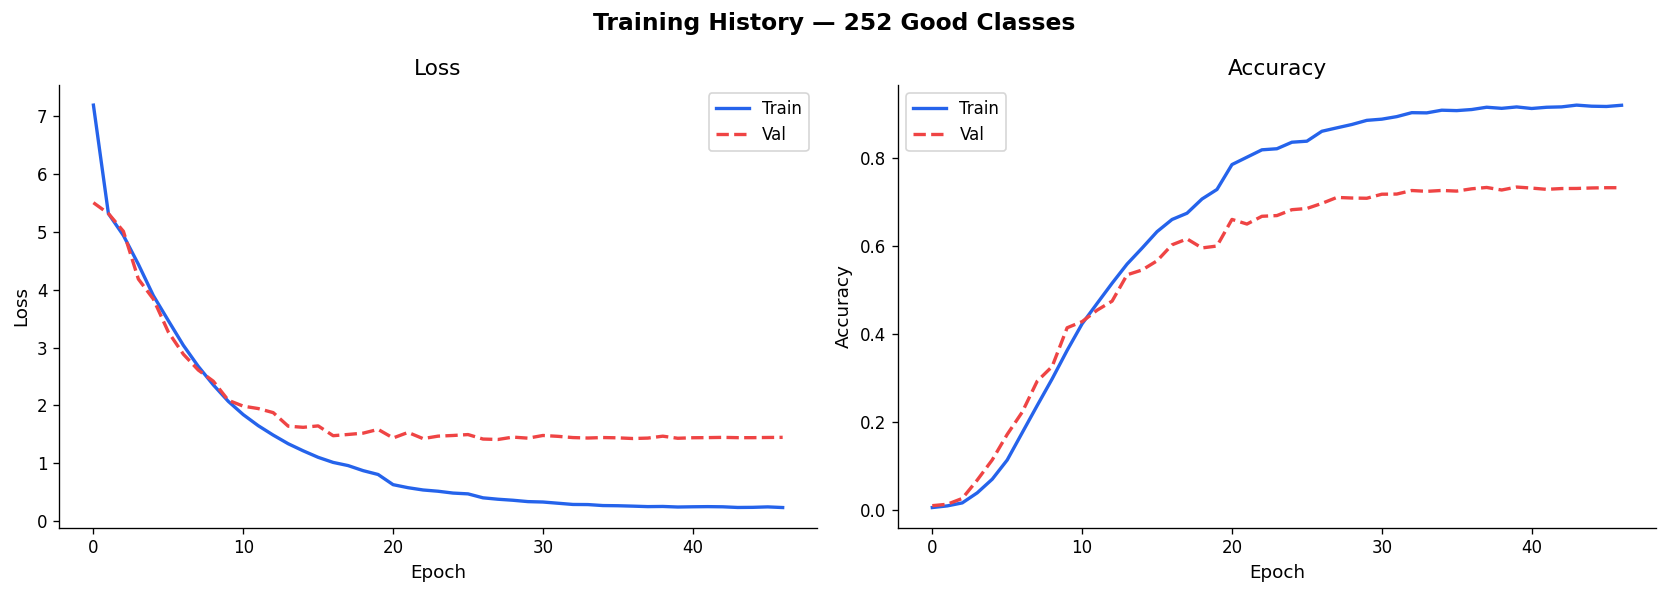

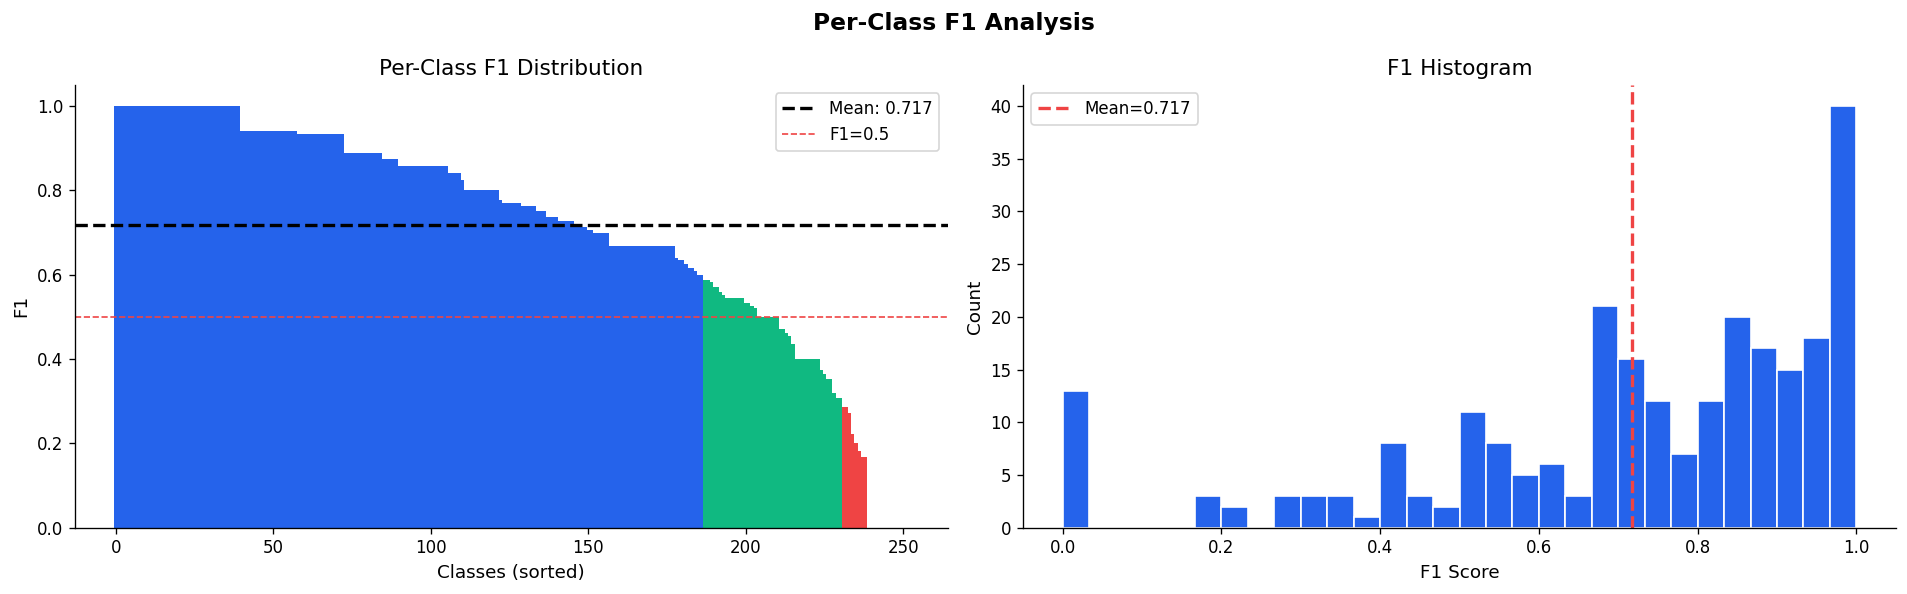

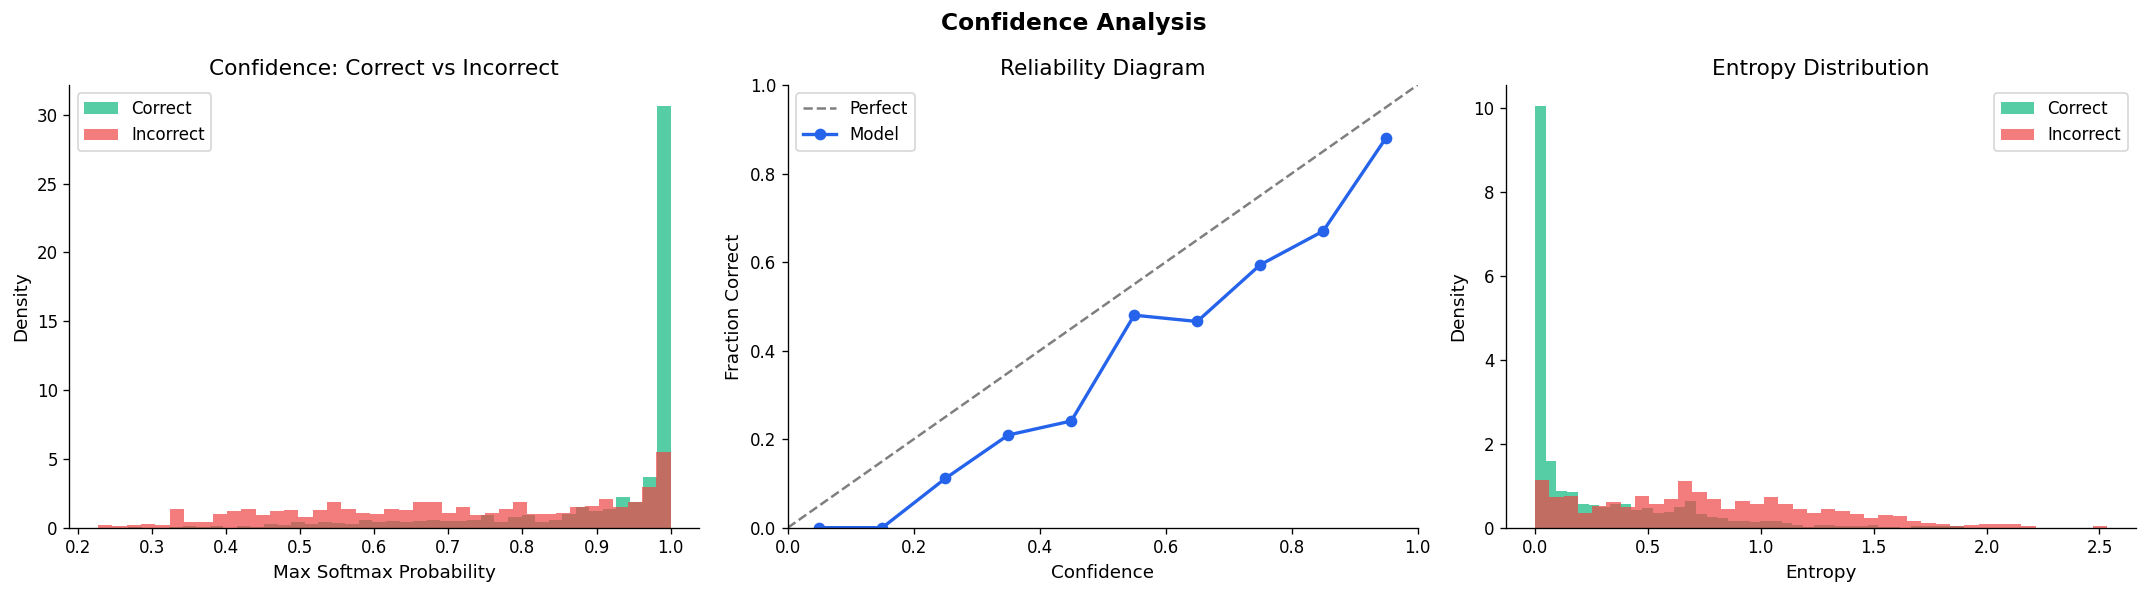

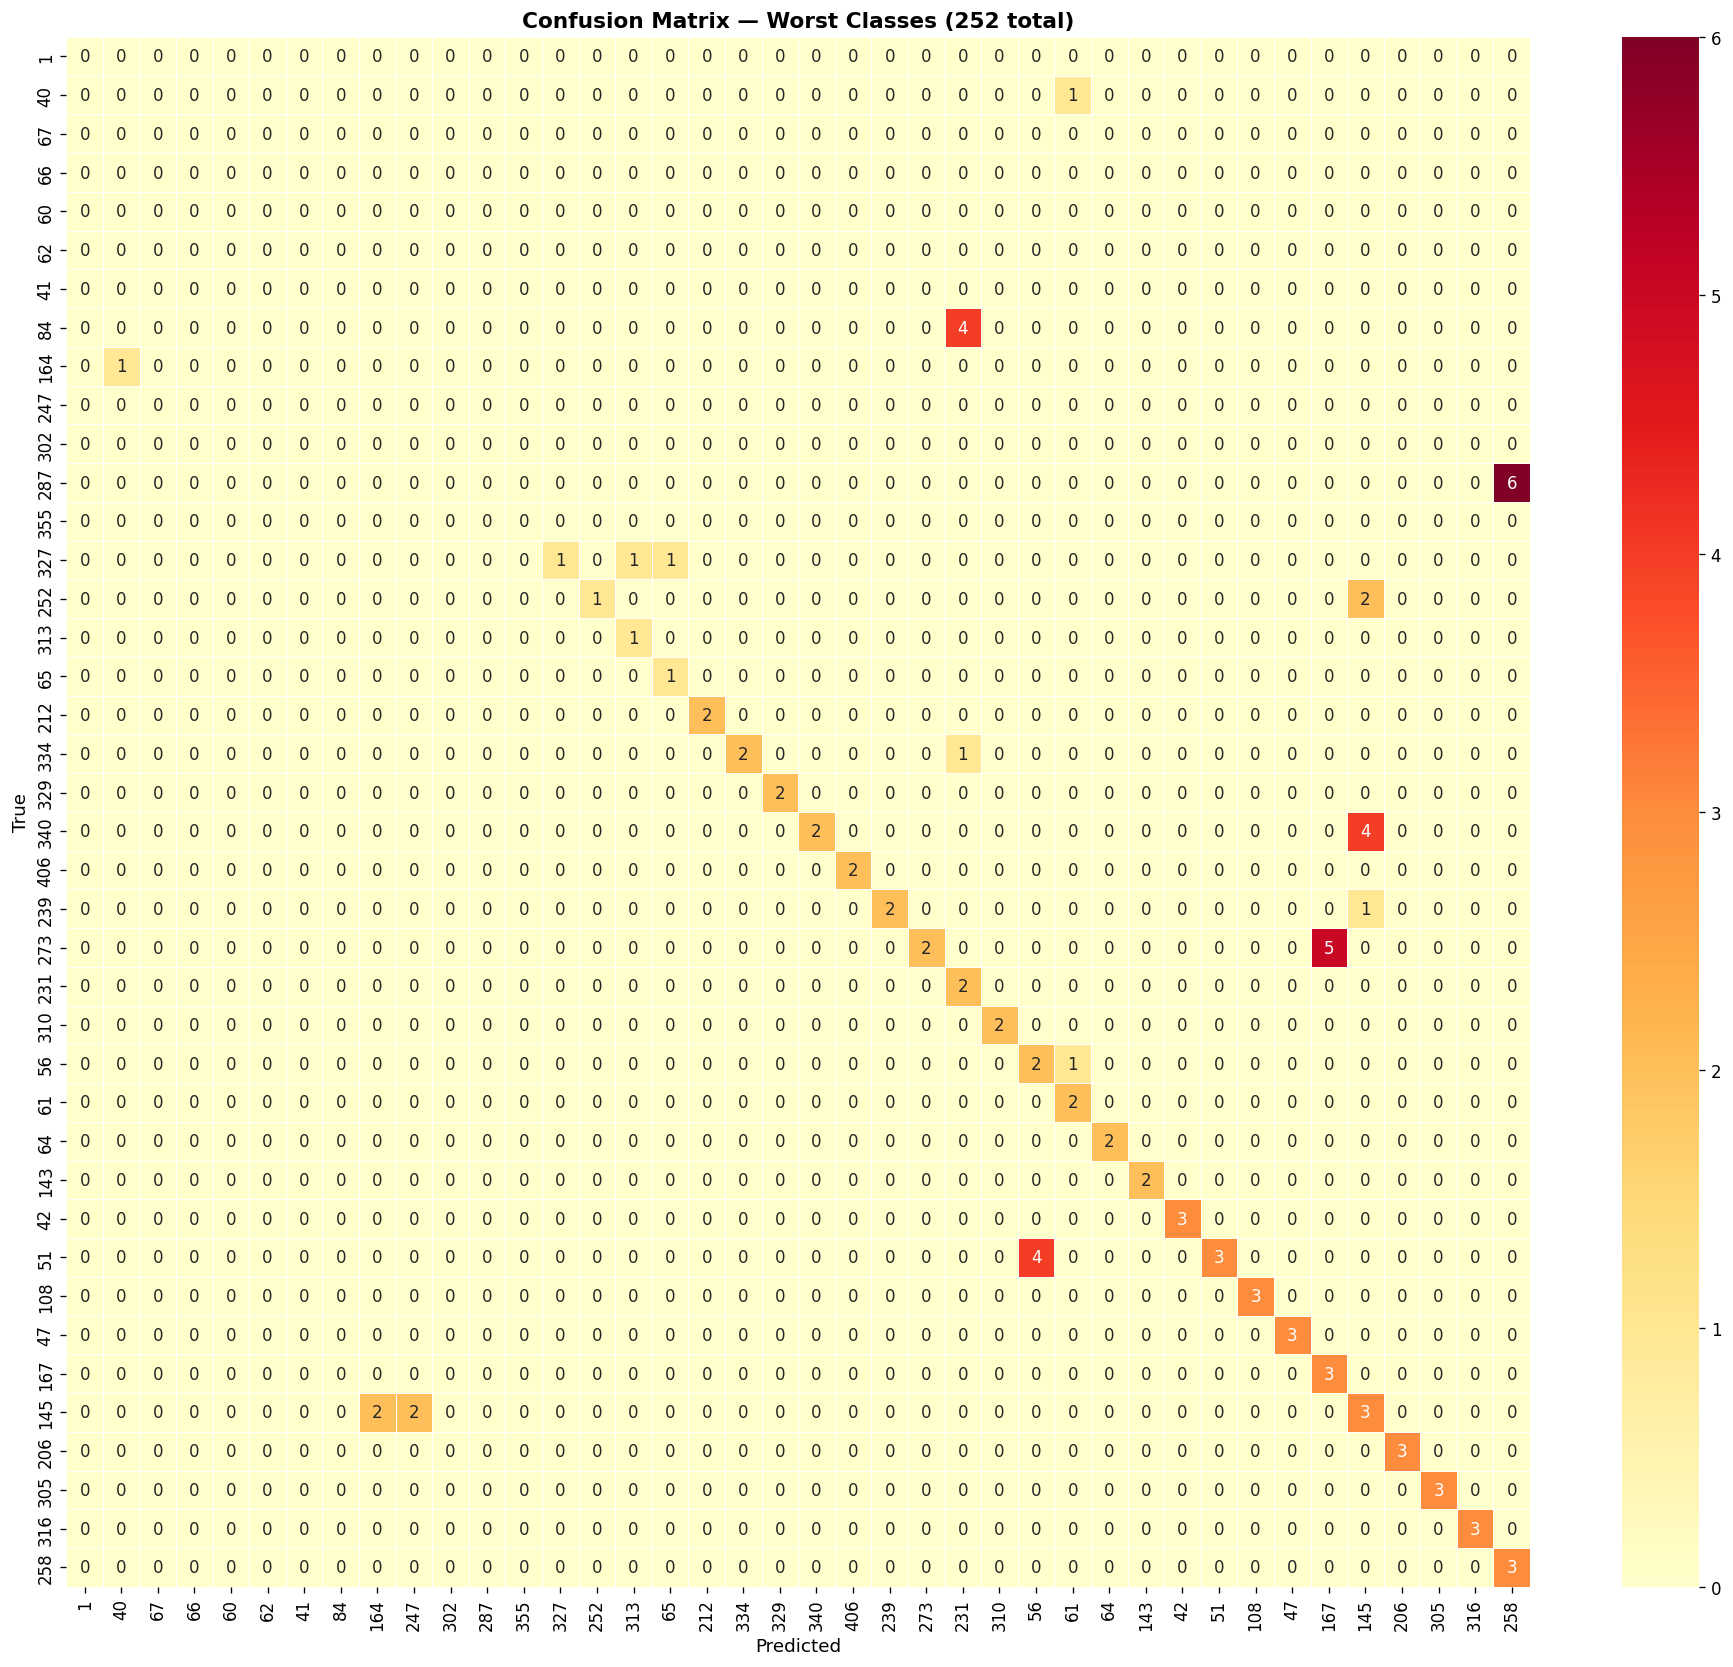

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 16: PLOTS
# ════════════════════════════════════════════════════════════════════════════════

hist_g     = history_good.history
epochs_ran = len(hist_g['loss'])

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Training History — {num_good} Good Classes",
             fontsize=14, fontweight='bold')
axes[0].plot(hist_g['loss'],     color=PALETTE[0], label='Train', linewidth=2)
axes[0].plot(hist_g['val_loss'], color=PALETTE[3], label='Val',
             linestyle='--', linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(hist_g['accuracy'],     color=PALETTE[0], label='Train', linewidth=2)
axes[1].plot(hist_g['val_accuracy'], color=PALETTE[3], label='Val',
             linestyle='--', linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{SAVE_PATH_GOOD}/training_curves.png", dpi=150)
plt.show()

# F1 distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Per-Class F1 Analysis", fontsize=14, fontweight='bold')
colors = [PALETTE[3] if v < 0.3 else PALETTE[1] if v < 0.6 else PALETTE[0]
          for v in sorted(f1_vals_g, reverse=True)]
axes[0].bar(range(num_good), sorted(f1_vals_g, reverse=True),
            color=colors, width=1.0, edgecolor='none')
axes[0].axhline(np.mean(f1_vals_g), color='black', linewidth=2,
                linestyle='--', label=f'Mean: {np.mean(f1_vals_g):.3f}')
axes[0].axhline(0.5, color=PALETTE[3], linewidth=1,
                linestyle='--', label='F1=0.5')
axes[0].set_xlabel("Classes (sorted)"); axes[0].set_ylabel("F1")
axes[0].set_title("Per-Class F1 Distribution"); axes[0].legend()
axes[1].hist(f1_vals_g, bins=30, color=PALETTE[0], edgecolor='white')
axes[1].axvline(np.mean(f1_vals_g), color=PALETTE[3], linewidth=2,
                linestyle='--', label=f'Mean={np.mean(f1_vals_g):.3f}')
axes[1].set_xlabel("F1 Score"); axes[1].set_ylabel("Count")
axes[1].set_title("F1 Histogram"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{SAVE_PATH_GOOD}/f1_distribution.png", dpi=150)
plt.show()

# Confidence analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confidence Analysis", fontsize=14, fontweight='bold')
axes[0].hist(max_conf_g[correct_mask_g],  bins=40, alpha=0.7,
             color=PALETTE[1], label='Correct',   density=True)
axes[0].hist(max_conf_g[~correct_mask_g], bins=40, alpha=0.7,
             color=PALETTE[3], label='Incorrect', density=True)
axes[0].set_xlabel("Max Softmax Probability")
axes[0].set_ylabel("Density")
axes[0].set_title("Confidence: Correct vs Incorrect")
axes[0].legend()
bins        = np.linspace(0, 1, 11)
bin_idx     = np.digitize(max_conf_g, bins) - 1
bin_acc     = [correct_mask_g[bin_idx == b].mean()
               if (bin_idx == b).sum() > 0 else 0
               for b in range(len(bins))]
bin_centers = (bins[:-1] + bins[1:]) / 2
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Perfect')
axes[1].plot(bin_centers[:len(bin_acc)-1], bin_acc[:-1],
             'o-', color=PALETTE[0], linewidth=2, label='Model')
axes[1].set_xlabel("Confidence"); axes[1].set_ylabel("Fraction Correct")
axes[1].set_title("Reliability Diagram")
axes[1].legend(); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)
entropy = -np.sum(y_pred_g * np.log(y_pred_g + 1e-12), axis=1)
axes[2].hist(entropy[correct_mask_g],  bins=40, alpha=0.7,
             color=PALETTE[1], label='Correct',   density=True)
axes[2].hist(entropy[~correct_mask_g], bins=40, alpha=0.7,
             color=PALETTE[3], label='Incorrect', density=True)
axes[2].set_xlabel("Entropy"); axes[2].set_ylabel("Density")
axes[2].set_title("Entropy Distribution"); axes[2].legend()
plt.tight_layout()
plt.savefig(f"{SAVE_PATH_GOOD}/confidence_analysis.png", dpi=150)
plt.show()

# Confusion matrix
cm        = confusion_matrix(y_true_cls_g, y_pred_cls_g,
                              labels=list(range(num_good)))
class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-8)
worst40   = np.argsort(class_acc)[:min(40, num_good)]
cm_sub    = cm[np.ix_(worst40, worst40)]
cm_labels = [str(le.classes_[le_good.classes_[i]]) for i in worst40]
plt.figure(figsize=(16, 14))
sns.heatmap(cm_sub, annot=True, fmt="d",
            xticklabels=cm_labels, yticklabels=cm_labels,
            cmap="YlOrRd", linewidths=0.3, linecolor='white')
plt.title(f"Confusion Matrix — Worst Classes ({num_good} total)",
          fontsize=13, fontweight='bold')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(f"{SAVE_PATH_GOOD}/confusion_matrix.png", dpi=150)
plt.show()

NameError: name 'good_f1' is not defined

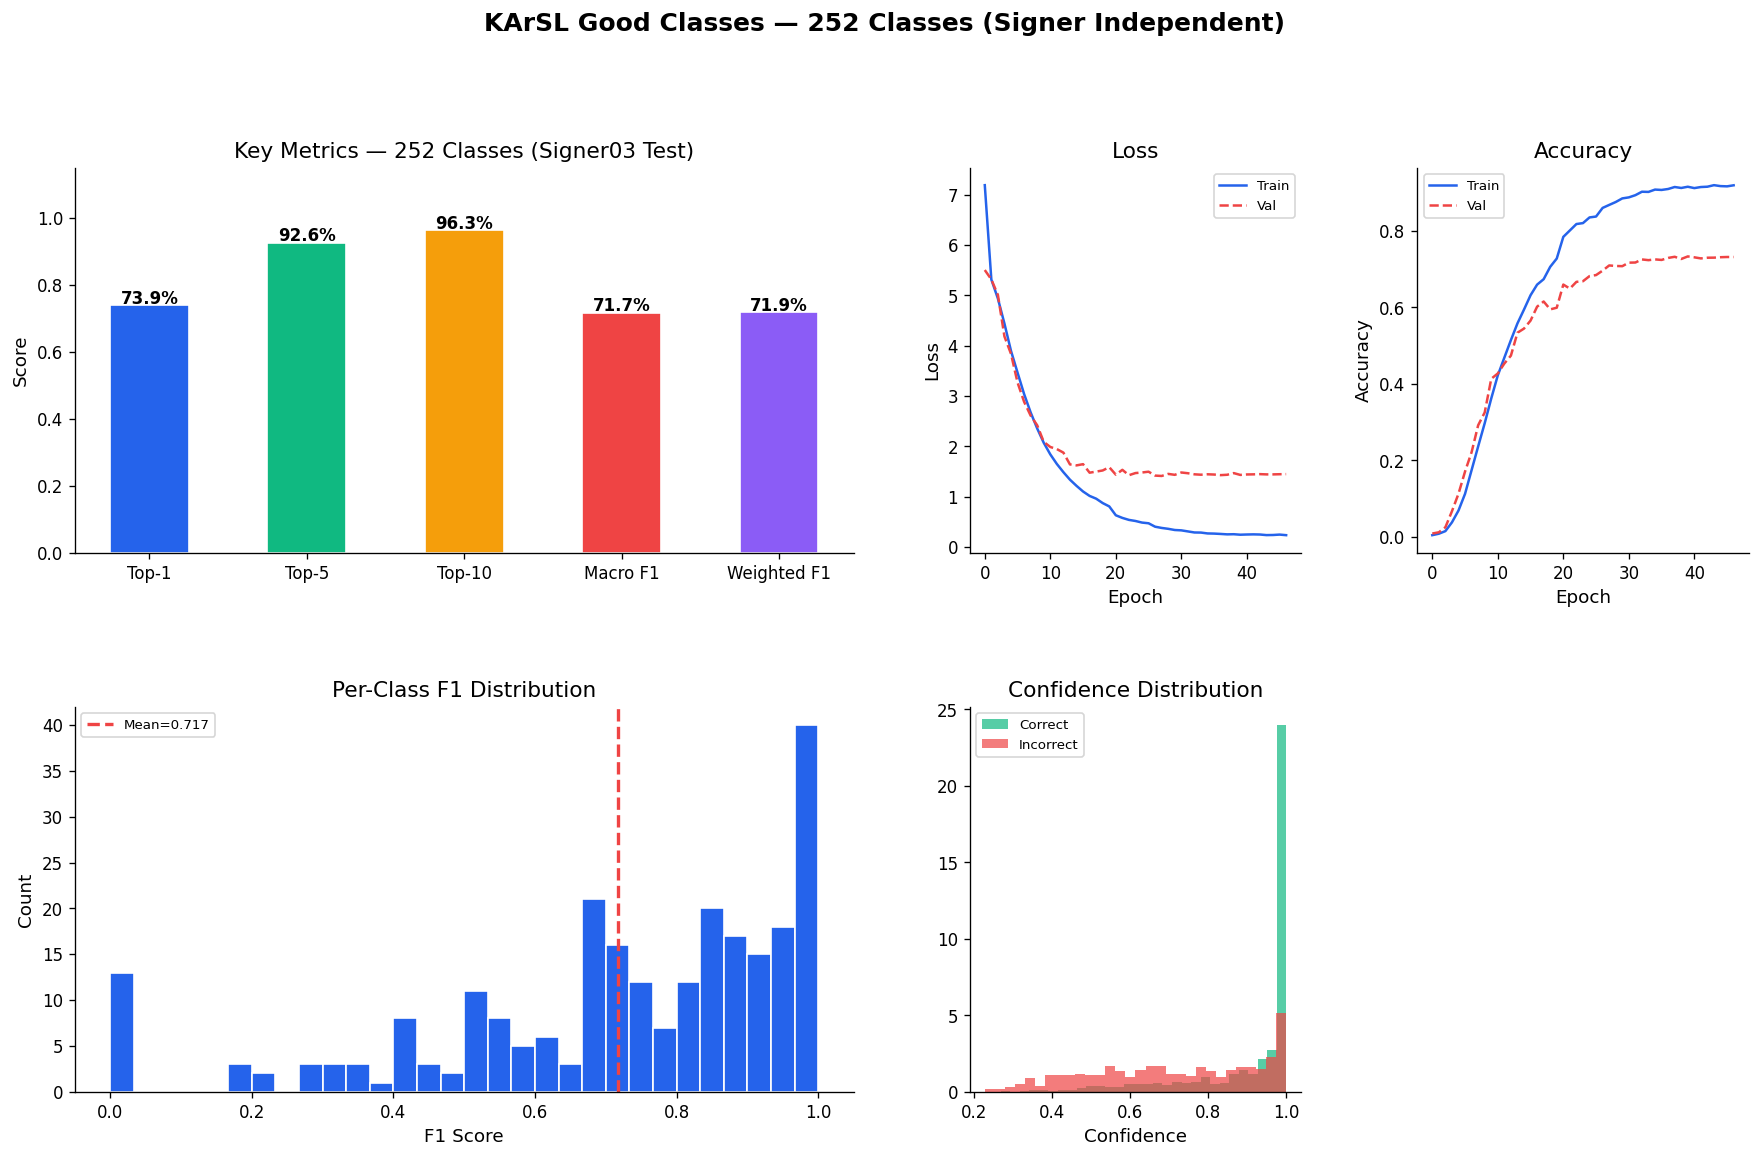

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 17: FINAL SUMMARY
# ════════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 10))
fig.suptitle(f"KArSL Good Classes — {num_good} Classes (Signer Independent)",
             fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

ax_m = fig.add_subplot(gs[0, 0:2])
names  = ['Top-1', 'Top-5', 'Top-10', 'Macro F1', 'Weighted F1']
values = [top1_g, top5_g, top10_g, macro_f1_g, weighted_f1_g]
bars   = ax_m.bar(names, values, color=PALETTE[:5],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax_m.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.005,
              f'{val*100:.1f}%', ha='center',
              fontsize=10, fontweight='bold')
ax_m.set_ylim(0, 1.15); ax_m.set_ylabel("Score")
ax_m.set_title(f"Key Metrics — {num_good} Classes (Signer03 Test)")

ax_l = fig.add_subplot(gs[0, 2])
ax_l.plot(hist_g['loss'],     color=PALETTE[0], label='Train')
ax_l.plot(hist_g['val_loss'], color=PALETTE[3], linestyle='--', label='Val')
ax_l.set_xlabel("Epoch"); ax_l.set_ylabel("Loss")
ax_l.set_title("Loss"); ax_l.legend(fontsize=8)

ax_a = fig.add_subplot(gs[0, 3])
ax_a.plot(hist_g['accuracy'],     color=PALETTE[0], label='Train')
ax_a.plot(hist_g['val_accuracy'], color=PALETTE[3], linestyle='--', label='Val')
ax_a.set_xlabel("Epoch"); ax_a.set_ylabel("Accuracy")
ax_a.set_title("Accuracy"); ax_a.legend(fontsize=8)

ax_f = fig.add_subplot(gs[1, 0:2])
ax_f.hist(f1_vals_g, bins=30, color=PALETTE[0], edgecolor='white')
ax_f.axvline(np.mean(f1_vals_g), color=PALETTE[3], linewidth=2,
             linestyle='--', label=f'Mean={np.mean(f1_vals_g):.3f}')
ax_f.set_xlabel("F1 Score"); ax_f.set_ylabel("Count")
ax_f.set_title("Per-Class F1 Distribution"); ax_f.legend(fontsize=8)

ax_c = fig.add_subplot(gs[1, 2])
ax_c.hist(max_conf_g[correct_mask_g],  bins=30, alpha=0.7,
          color=PALETTE[1], label='Correct',   density=True)
ax_c.hist(max_conf_g[~correct_mask_g], bins=30, alpha=0.7,
          color=PALETTE[3], label='Incorrect', density=True)
ax_c.set_xlabel("Confidence")
ax_c.set_title("Confidence Distribution"); ax_c.legend(fontsize=8)

ax_i = fig.add_subplot(gs[1, 3])
ax_i.axis('off')
info = (
    f"Architecture : TCN\n"
    f"Features     : Hands only (126)\n"
    f"Frames       : {MAX_FRAMES}\n"
    f"Classes      : {num_good}\n"
    f"  f1>=0.5:   {len(good_f1)}\n"
    f"  alphabet:  {len(good_alphabet)}\n\n"
    f"Train: S01+S02 ({len(y_train_g):,})\n"
    f"Val:   S03 train ({len(y_val_g):,})\n"
    f"Test:  S03 test ({len(y_test_g):,})\n\n"
    f"Top-1    : {top1_g*100:.2f}%\n"
    f"Top-5    : {top5_g*100:.2f}%\n"
    f"Macro F1 : {macro_f1_g*100:.2f}%\n\n"
    f"vs Full (417):\n"
    f"Top-1    : {top1*100:.2f}%\n"
    f"Macro F1 : {macro_f1*100:.2f}%"
)
ax_i.text(0.05, 0.95, info, transform=ax_i.transAxes,
          fontsize=9, va='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#F8FAFC', alpha=0.8))
ax_i.set_title("Run Configuration")

plt.savefig(f"{SAVE_PATH_GOOD}/final_summary.png",
            bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 18: SAVE MODEL AND TFLITE
# ════════════════════════════════════════════════════════════════════════════════

model_good.save(f"{SAVE_PATH_GOOD}/model_good.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model_good)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite = converter.convert()
with open(f"{SAVE_PATH_GOOD}/model_good.tflite", "wb") as f:
    f.write(tflite)

import json
label_map = {}
for i in range(num_good):
    orig_mapped = le_good.classes_[i]
    orig_label  = le.classes_[orig_mapped]
    word = karsl_df[karsl_df["ClassIndex"] == orig_label]["Sign-Arabic"].values
    eng  = karsl_df[karsl_df["ClassIndex"] == orig_label]["Sign-English"].values
    label_map[str(i)] = {
        "orig_label":   int(orig_label),
        "sign_arabic":  word[0] if len(word) > 0 else "?",
        "sign_english": eng[0]  if len(eng)  > 0 else "?"
    }

with open(f"{SAVE_PATH_GOOD}/label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print(f"✓ TFLite:  {len(tflite)/(1024*1024):.2f} MB")
print(f"✓ Classes: {num_good}")
print(f"✓ Saved:   {SAVE_PATH_GOOD}")

Saved artifact at '/tmp/tmp8m5j0l71'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 126), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 252), dtype=tf.float32, name=None)
Captures:
  136347015709328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136346384254736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136348167765456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136348167765264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136348167754512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136345690540176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136345690538448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136345690538064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136345690539792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136345690539216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136345690554000:

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 8: EVALUATE
# ════════════════════════════════════════════════════════════════════════════════

y_test_cat = to_categorical(y_test, num_classes)
y_pred     = model.predict(X_test, batch_size=64, verbose=1)
y_pred_cls = np.argmax(y_pred,     axis=1)
y_true_cls = np.argmax(y_test_cat, axis=1)

top1        = np.mean(y_pred_cls == y_true_cls)
top5        = np.mean([y_true_cls[i] in np.argsort(y_pred[i])[-5:]
                       for i in range(len(y_true_cls))])
top10       = np.mean([y_true_cls[i] in np.argsort(y_pred[i])[-10:]
                       for i in range(len(y_true_cls))])
macro_f1    = f1_score(y_true_cls, y_pred_cls, average='macro',    zero_division=0)
weighted_f1 = f1_score(y_true_cls, y_pred_cls, average='weighted', zero_division=0)

print("=" * 55)
print("EVALUATION — SIGNER03 TEST SET")
print("=" * 55)
print(f"  Top-1  Accuracy : {top1*100:.2f}%")
print(f"  Top-5  Accuracy : {top5*100:.2f}%")
print(f"  Top-10 Accuracy : {top10*100:.2f}%")
print(f"  Macro  F1       : {macro_f1*100:.2f}%")
print(f"  Weighted F1     : {weighted_f1*100:.2f}%")
print("=" * 55)

# Save predictions
np.save(f"{SAVE_PATH}/y_pred.npy",     y_pred)
np.save(f"{SAVE_PATH}/y_pred_cls.npy", y_pred_cls)
np.save(f"{SAVE_PATH}/y_true_cls.npy", y_true_cls)
print("✓ Predictions saved")

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step
EVALUATION — SIGNER03 TEST SET
  Top-1  Accuracy : 54.54%
  Top-5  Accuracy : 76.95%
  Top-10 Accuracy : 82.26%
  Macro  F1       : 49.93%
  Weighted F1     : 50.07%
✓ Predictions saved


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 9: PLOTS AND METRICS
# ════════════════════════════════════════════════════════════════════════════════

# Load predictions if needed after disconnect
y_pred     = np.load(f"{SAVE_PATH}/y_pred.npy")
y_pred_cls = np.load(f"{SAVE_PATH}/y_pred_cls.npy")
y_true_cls = np.load(f"{SAVE_PATH}/y_true_cls.npy")
max_conf   = y_pred.max(axis=1)
correct_mask = (y_pred_cls == y_true_cls)

# Per-class report
report      = classification_report(y_true_cls, y_pred_cls,
                                     zero_division=0, output_dict=True)
report_rows = []
for i in range(num_classes):
    orig = le.classes_[i]
    word = karsl_df[karsl_df["ClassIndex"] == orig]["Sign-Arabic"].values
    word = word[0] if len(word) > 0 else "?"
    d    = report.get(str(i), {"precision":0,"recall":0,
                                "f1-score":0,"support":0})
    report_rows.append({
        "class_idx":   i,
        "orig_label":  orig,
        "sign_arabic": word,
        "precision":   round(d["precision"], 3),
        "recall":      round(d["recall"],    3),
        "f1_score":    round(d["f1-score"],  3),
        "support":     int(d["support"])
    })

report_df = pd.DataFrame(report_rows).sort_values("f1_score", ascending=False)
report_df.to_csv(f"{SAVE_PATH}/per_class_f1.csv",
                 index=False, encoding="utf-8-sig")

print("Top 10:"); print(report_df[["orig_label","sign_arabic",
                                    "f1_score","support"]].head(10).to_string(index=False))
print("\nBottom 10:"); print(report_df[["orig_label","sign_arabic",
                                         "f1_score","support"]].tail(10).to_string(index=False))

f1_vals = report_df["f1_score"].values

Top 10:
 orig_label       sign_arabic  f1_score  support
        378     مبطلات الصلاة       1.0        8
        373      أركان الصلاة       1.0        8
         36                 ح       1.0        6
        339 كاميرا فوتوغرافية       1.0        8
        323             إبريق       1.0        8
         35                 ج       1.0       10
         53                 ل       1.0        8
        367            العمرة       1.0        8
        160              يشرب       1.0        8
        168              يفتح       1.0        8

Bottom 10:
 orig_label    sign_arabic  f1_score  support
         77    شهيق - زفير       0.0        8
         81            كبد       0.0        8
         67              ى       0.0        8
        368           الحج       0.0        8
        362  أركان الإيمان       0.0        8
        364  يصلي / الصلاة       0.0        8
        376             شر       0.0        8
          6              6       0.0        8
        370           رسول 

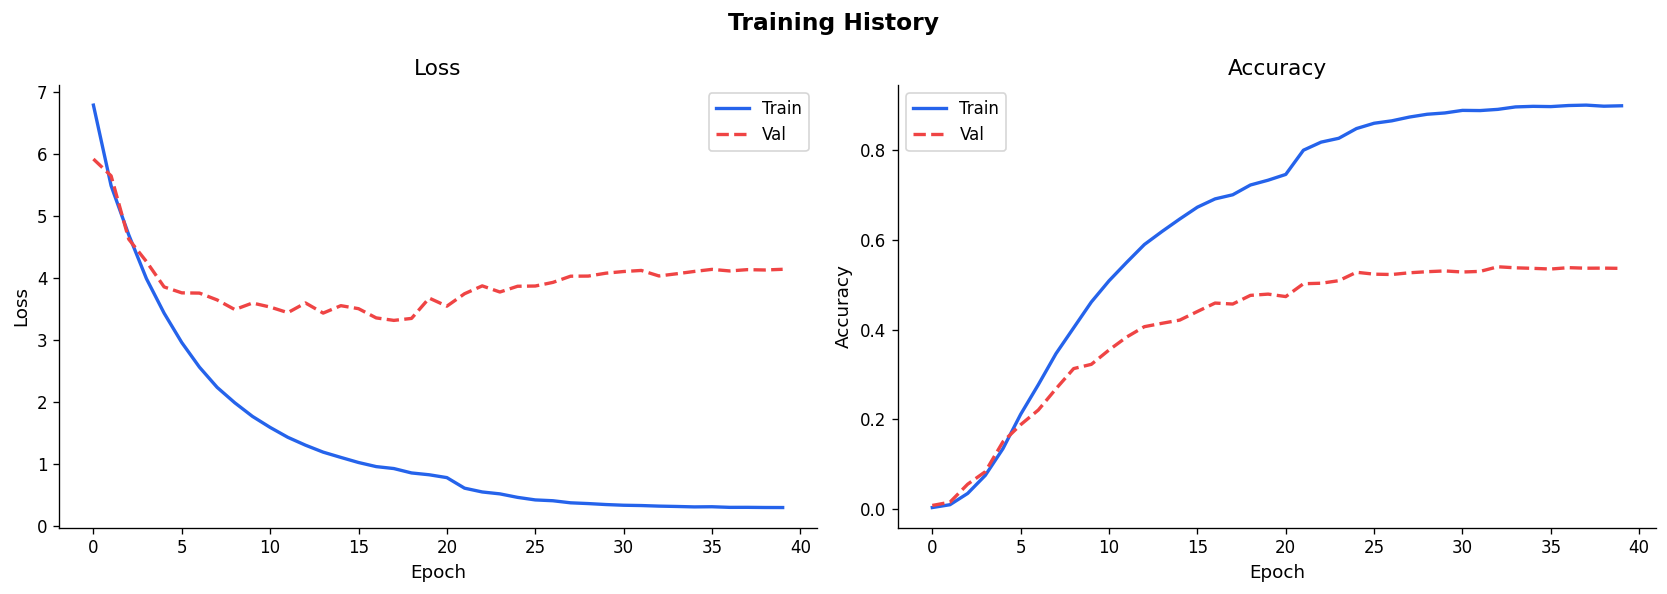

In [ ]:
# ── Training curves ────────────────────────────────────────────────────────────
hist = history.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=14, fontweight='bold')

axes[0].plot(hist['loss'],     color=PALETTE[0], label='Train', linewidth=2)
axes[0].plot(hist['val_loss'], color=PALETTE[3], label='Val',
             linestyle='--',   linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss");   axes[0].legend()

axes[1].plot(hist['accuracy'],     color=PALETTE[0], label='Train', linewidth=2)
axes[1].plot(hist['val_accuracy'], color=PALETTE[3], label='Val',
             linestyle='--',       linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/training_curves.png", dpi=150)
plt.show()

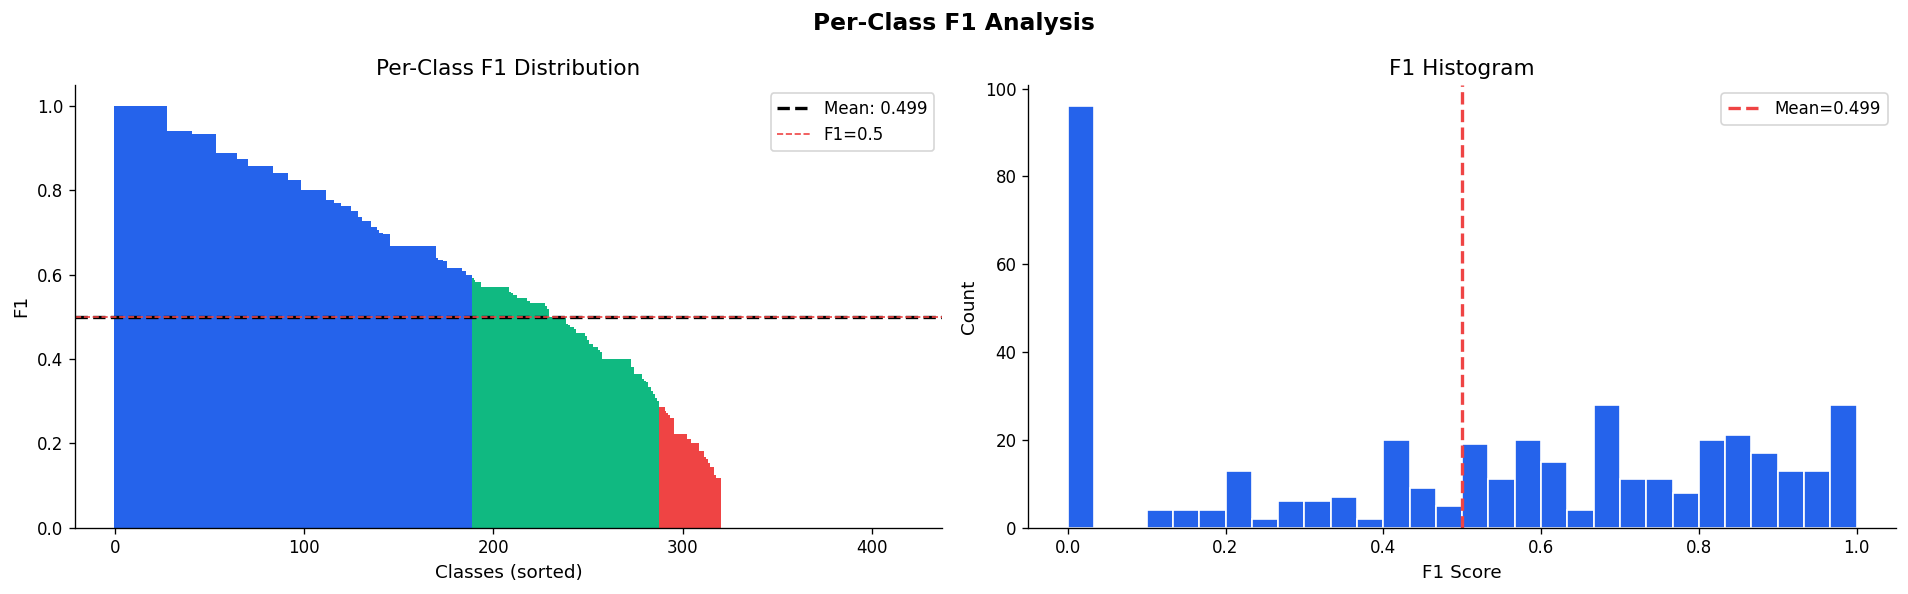

In [ ]:
# ── F1 distribution ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Per-Class F1 Analysis", fontsize=14, fontweight='bold')

colors = [PALETTE[3] if v < 0.3 else PALETTE[1] if v < 0.6 else PALETTE[0]
          for v in sorted(f1_vals, reverse=True)]
axes[0].bar(range(num_classes), sorted(f1_vals, reverse=True),
            color=colors, width=1.0, edgecolor='none')
axes[0].axhline(np.mean(f1_vals), color='black', linewidth=2,
                linestyle='--', label=f'Mean: {np.mean(f1_vals):.3f}')
axes[0].axhline(0.5, color=PALETTE[3], linewidth=1,
                linestyle='--', label='F1=0.5')
axes[0].set_xlabel("Classes (sorted)"); axes[0].set_ylabel("F1")
axes[0].set_title("Per-Class F1 Distribution"); axes[0].legend()

axes[1].hist(f1_vals, bins=30, color=PALETTE[0], edgecolor='white')
axes[1].axvline(np.mean(f1_vals), color=PALETTE[3], linewidth=2,
                linestyle='--', label=f'Mean={np.mean(f1_vals):.3f}')
axes[1].set_xlabel("F1 Score"); axes[1].set_ylabel("Count")
axes[1].set_title("F1 Histogram"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/f1_distribution.png", dpi=150)
plt.show()

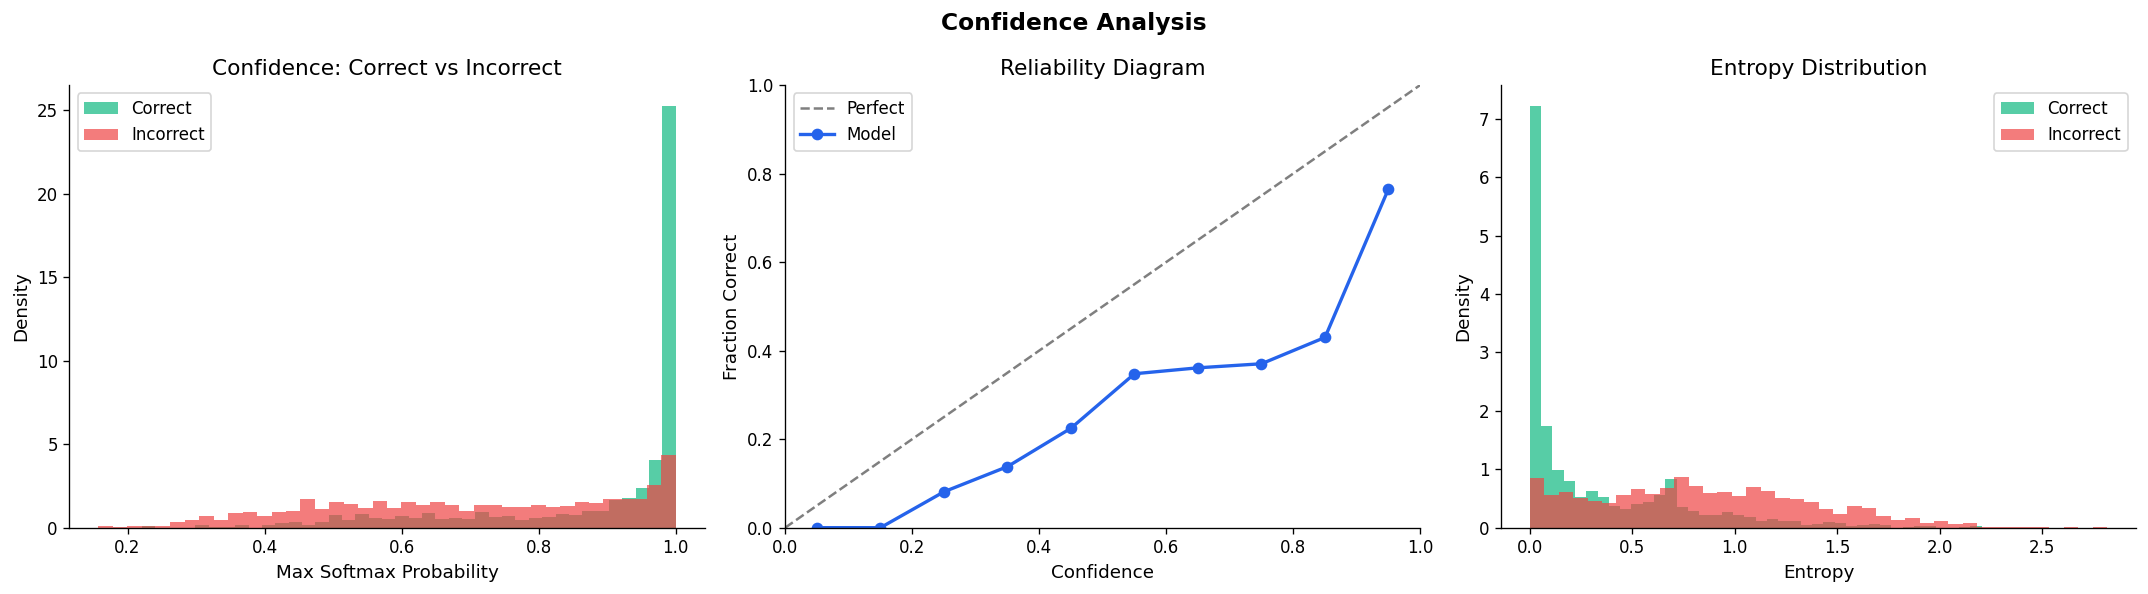

In [ ]:
# ── Confidence analysis ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confidence Analysis", fontsize=14, fontweight='bold')

axes[0].hist(max_conf[correct_mask],  bins=40, alpha=0.7,
             color=PALETTE[1], label='Correct',   density=True)
axes[0].hist(max_conf[~correct_mask], bins=40, alpha=0.7,
             color=PALETTE[3], label='Incorrect', density=True)
axes[0].set_xlabel("Max Softmax Probability")
axes[0].set_ylabel("Density")
axes[0].set_title("Confidence: Correct vs Incorrect")
axes[0].legend()

bins        = np.linspace(0, 1, 11)
bin_idx     = np.digitize(max_conf, bins) - 1
bin_acc     = [correct_mask[bin_idx == b].mean()
               if (bin_idx == b).sum() > 0 else 0
               for b in range(len(bins))]
bin_centers = (bins[:-1] + bins[1:]) / 2
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Perfect')
axes[1].plot(bin_centers[:len(bin_acc)-1], bin_acc[:-1],
             'o-', color=PALETTE[0], linewidth=2, label='Model')
axes[1].set_xlabel("Confidence"); axes[1].set_ylabel("Fraction Correct")
axes[1].set_title("Reliability Diagram")
axes[1].legend(); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)

entropy = -np.sum(y_pred * np.log(y_pred + 1e-12), axis=1)
axes[2].hist(entropy[correct_mask],  bins=40, alpha=0.7,
             color=PALETTE[1], label='Correct',   density=True)
axes[2].hist(entropy[~correct_mask], bins=40, alpha=0.7,
             color=PALETTE[3], label='Incorrect', density=True)
axes[2].set_xlabel("Entropy"); axes[2].set_ylabel("Density")
axes[2].set_title("Entropy Distribution"); axes[2].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/confidence_analysis.png", dpi=150)
plt.show()

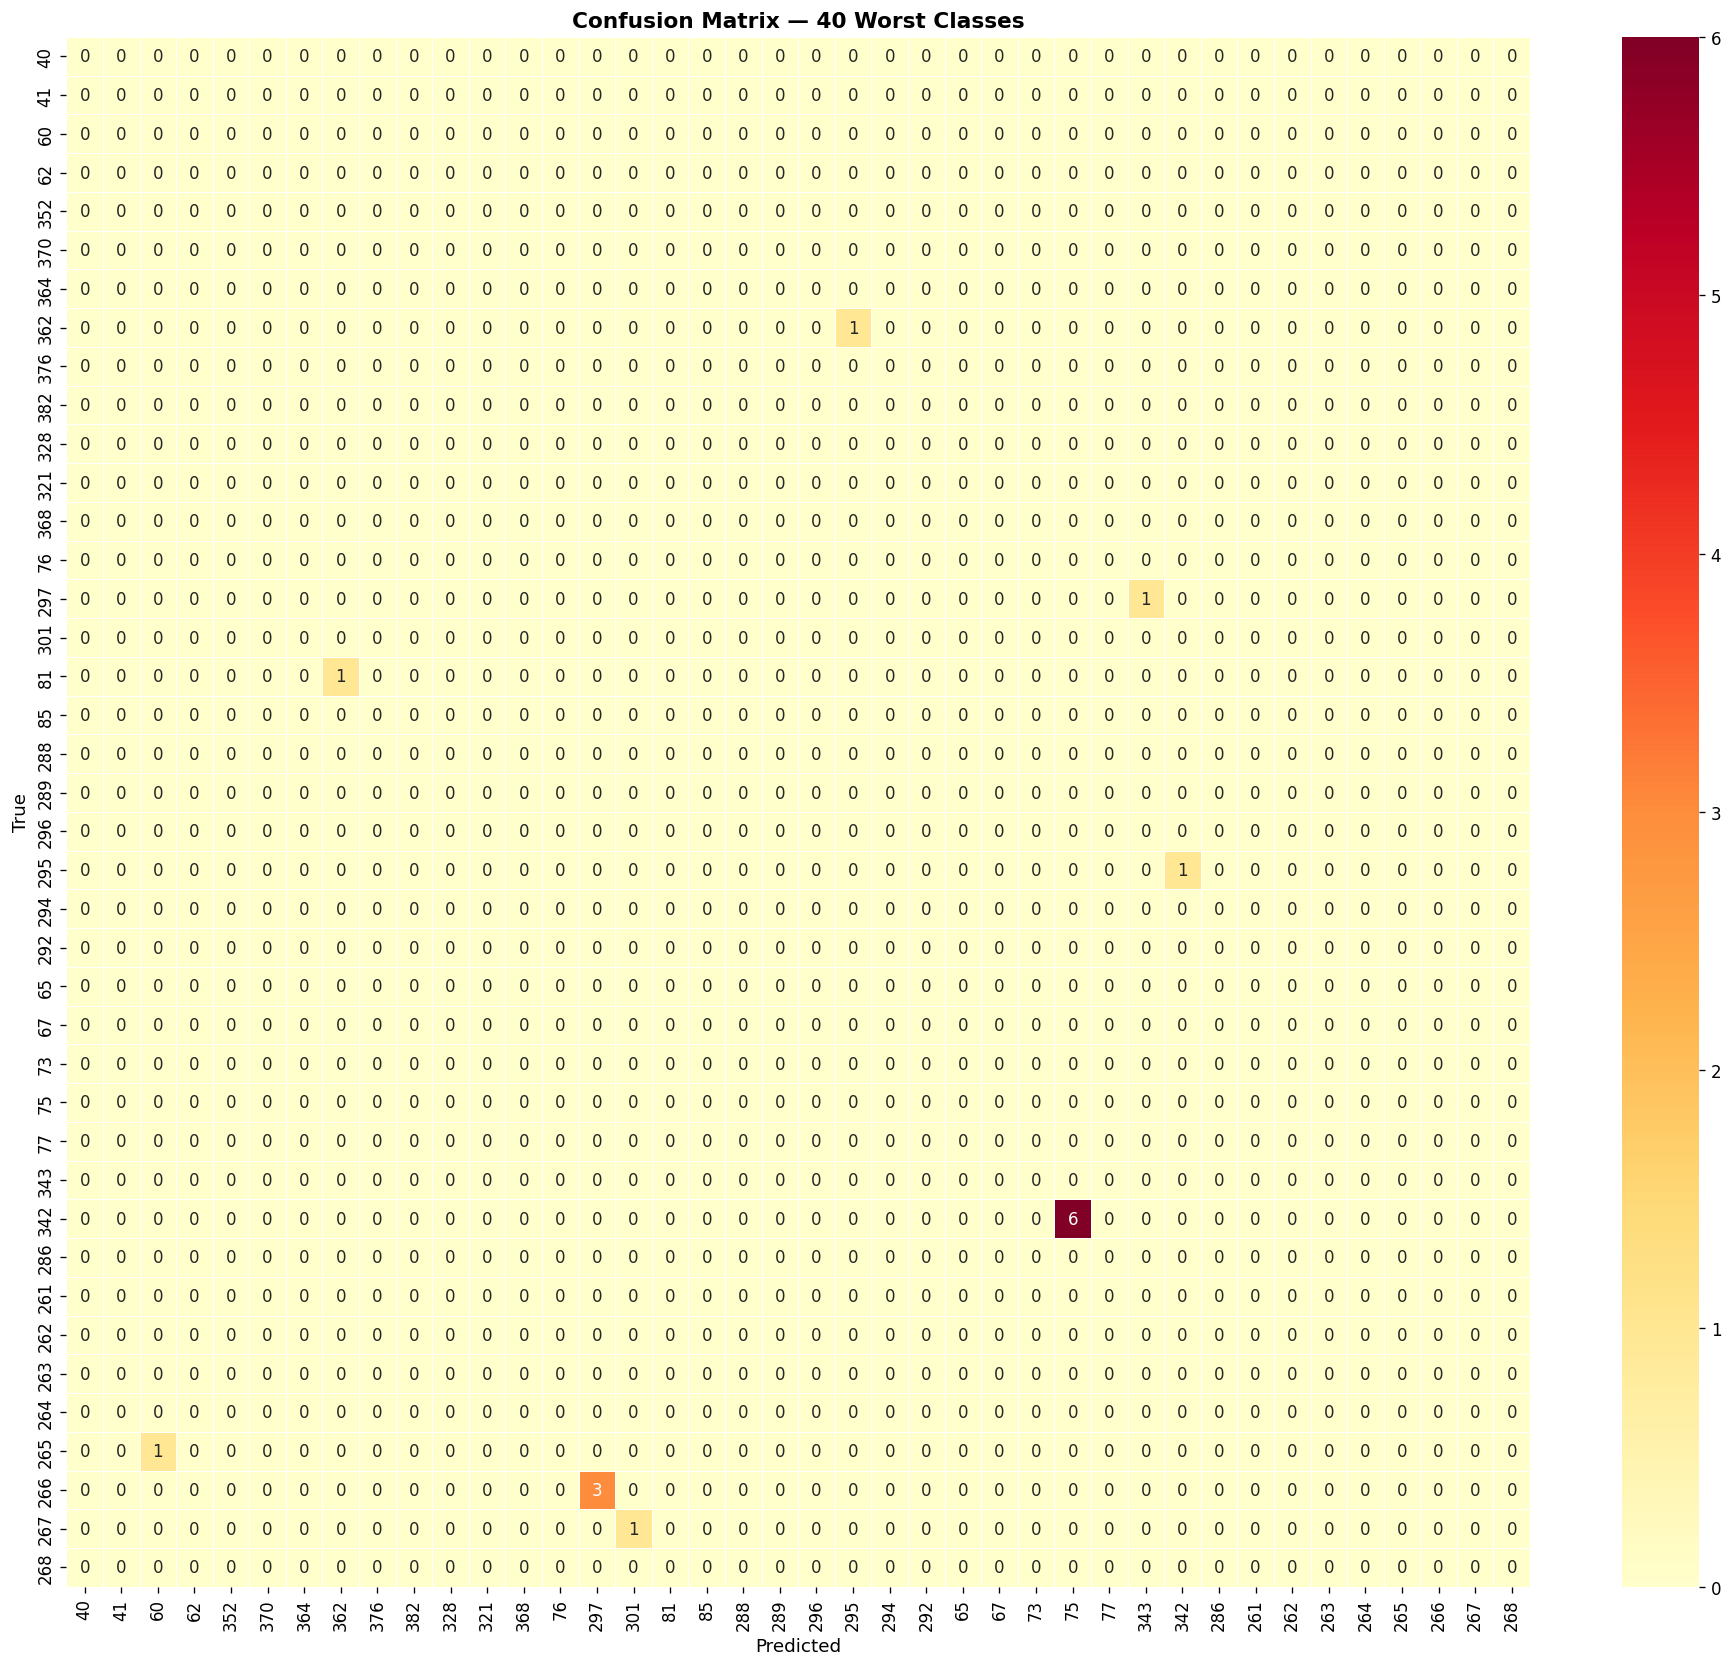

In [ ]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
cm        = confusion_matrix(y_true_cls, y_pred_cls,
                              labels=list(range(num_classes)))
class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-8)
worst40   = np.argsort(class_acc)[:40]
cm_sub    = cm[np.ix_(worst40, worst40)]
cm_labels = [str(le.classes_[i]) for i in worst40]

plt.figure(figsize=(16, 14))
sns.heatmap(cm_sub, annot=True, fmt="d",
            xticklabels=cm_labels, yticklabels=cm_labels,
            cmap="YlOrRd", linewidths=0.3, linecolor='white')
plt.title("Confusion Matrix — 40 Worst Classes",
          fontsize=13, fontweight='bold')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/confusion_matrix.png", dpi=150)
plt.show()

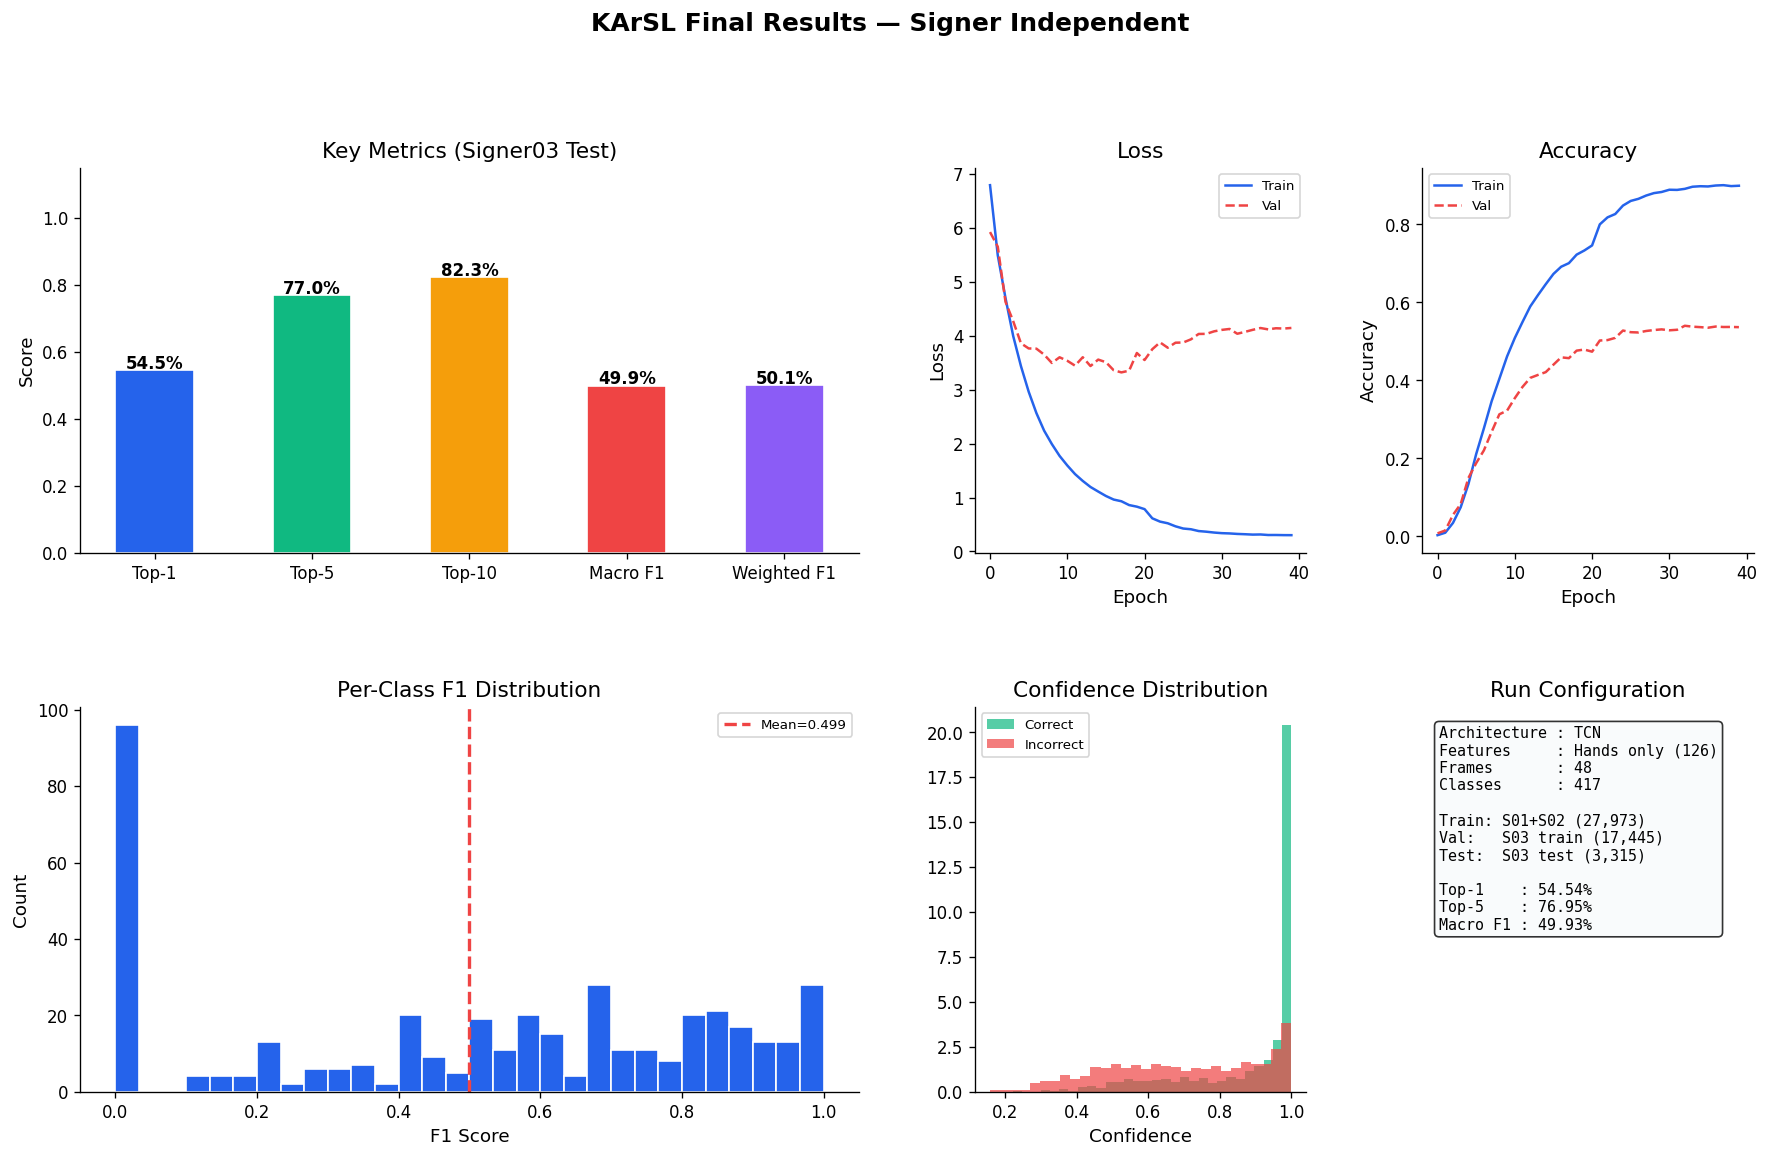

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 10: FINAL SUMMARY
# ════════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 10))
fig.suptitle("KArSL Final Results — Signer Independent",
             fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

ax_m = fig.add_subplot(gs[0, 0:2])
names  = ['Top-1', 'Top-5', 'Top-10', 'Macro F1', 'Weighted F1']
values = [top1, top5, top10, macro_f1, weighted_f1]
bars   = ax_m.bar(names, values, color=PALETTE[:5],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax_m.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.005,
              f'{val*100:.1f}%', ha='center',
              fontsize=10, fontweight='bold')
ax_m.set_ylim(0, 1.15)
ax_m.set_ylabel("Score")
ax_m.set_title("Key Metrics (Signer03 Test)")

ax_l = fig.add_subplot(gs[0, 2])
ax_l.plot(hist['loss'],     color=PALETTE[0], label='Train')
ax_l.plot(hist['val_loss'], color=PALETTE[3], linestyle='--', label='Val')
ax_l.set_xlabel("Epoch"); ax_l.set_ylabel("Loss")
ax_l.set_title("Loss"); ax_l.legend(fontsize=8)

ax_a = fig.add_subplot(gs[0, 3])
ax_a.plot(hist['accuracy'],     color=PALETTE[0], label='Train')
ax_a.plot(hist['val_accuracy'], color=PALETTE[3], linestyle='--', label='Val')
ax_a.set_xlabel("Epoch"); ax_a.set_ylabel("Accuracy")
ax_a.set_title("Accuracy"); ax_a.legend(fontsize=8)

ax_f = fig.add_subplot(gs[1, 0:2])
ax_f.hist(f1_vals, bins=30, color=PALETTE[0], edgecolor='white')
ax_f.axvline(np.mean(f1_vals), color=PALETTE[3], linewidth=2,
             linestyle='--', label=f'Mean={np.mean(f1_vals):.3f}')
ax_f.set_xlabel("F1 Score"); ax_f.set_ylabel("Count")
ax_f.set_title("Per-Class F1 Distribution"); ax_f.legend(fontsize=8)

ax_c = fig.add_subplot(gs[1, 2])
ax_c.hist(max_conf[correct_mask],  bins=30, alpha=0.7,
          color=PALETTE[1], label='Correct',   density=True)
ax_c.hist(max_conf[~correct_mask], bins=30, alpha=0.7,
          color=PALETTE[3], label='Incorrect', density=True)
ax_c.set_xlabel("Confidence")
ax_c.set_title("Confidence Distribution"); ax_c.legend(fontsize=8)

ax_i = fig.add_subplot(gs[1, 3])
ax_i.axis('off')
info = (
    f"Architecture : TCN\n"
    f"Features     : Hands only (126)\n"
    f"Frames       : {MAX_FRAMES}\n"
    f"Classes      : {num_classes}\n\n"
    f"Train: S01+S02 ({len(y_train):,})\n"
    f"Val:   S03 train ({len(y_val):,})\n"
    f"Test:  S03 test ({len(y_test):,})\n\n"
    f"Top-1    : {top1*100:.2f}%\n"
    f"Top-5    : {top5*100:.2f}%\n"
    f"Macro F1 : {macro_f1*100:.2f}%"
)
ax_i.text(0.05, 0.95, info, transform=ax_i.transAxes,
          fontsize=9, va='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#F8FAFC', alpha=0.8))
ax_i.set_title("Run Configuration")

plt.savefig(f"{SAVE_PATH}/final_summary.png", bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# INVESTIGATION: Training samples per class
# ════════════════════════════════════════════════════════════════════════════════

from collections import Counter
import pandas as pd

# Count samples per original label in train
train_counts = Counter(v[2] for v in vl_train)

# Build investigation dataframe
rows = []
for orig_label, count in sorted(train_counts.items()):
    word = karsl_df[karsl_df["ClassIndex"] == orig_label]["Sign-Arabic"].values
    word = word[0] if len(word) > 0 else "?"
    rows.append({
        "orig_label":  orig_label,
        "sign_arabic": word,
        "train_count": count
    })

inv_df = pd.DataFrame(rows).sort_values("train_count")

print(f"Total classes in train: {len(inv_df)}")
print(f"\nSample count distribution:")
print(f"  Min:  {inv_df['train_count'].min()}")
print(f"  Max:  {inv_df['train_count'].max()}")
print(f"  Mean: {inv_df['train_count'].mean():.1f}")

print(f"\nClasses with < 50 samples (underrepresented):")
under = inv_df[inv_df['train_count'] < 50]
print(under[["orig_label","sign_arabic","train_count"]].to_string(index=False))

print(f"\nClasses with >= 50 samples: {(inv_df['train_count'] >= 50).sum()}")

Total classes in train: 460

Sample count distribution:
  Min:  10
  Max:  126
  Mean: 80.2

Classes with < 50 samples (underrepresented):
 orig_label    sign_arabic  train_count
        459 مصور فوتوغرافي           10
        435           حلال           40
        446            نبي           40
        455           فروض           41
        429          النار           41
        432         واجبات           41
        447          هداية           41
        448          أمانة           41
        451  عقوق الوالدين           41
        445           صدقة           41
        417      الحمد لله           42
        419          إيمان           42
        420    الشرك بالله           42
        421     أعوذ بالله           42
        454  عيد رأس السنة           42
        436           حرام           42
        437          مغفرة           42
        428          الجنة           42
        433          حسنات           42
        431           حقوق           42
        422          

In [ ]:
# Rebuild s01_classes from vl_s01_train
s01_classes = set(v[2] for v in vl_s01_train)
print(f"S01 classes: {len(s01_classes)}")

S01 classes: 417


In [ ]:
# Count training samples per original label — filtered to 417 classes
train_counts = Counter(v[2] for v in vl_train if v[2] in s01_classes)

# Build full analysis — only 417 classes
rows = []
for i in range(num_classes):
    orig_label = int(le.classes_[i])

    # Only include if in s01_classes
    if orig_label not in s01_classes:
        continue

    # Arabic word
    word = karsl_df[karsl_df["ClassIndex"] == orig_label]["Sign-Arabic"].values
    word = word[0] if len(word) > 0 else "?"

    # English word
    eng  = karsl_df[karsl_df["ClassIndex"] == orig_label]["Sign-English"].values
    eng  = eng[0] if len(eng) > 0 else "?"

    # Training samples
    train_count = train_counts.get(orig_label, 0)

    # F1 metrics
    f1_row = report_df[report_df["orig_label"] == orig_label]
    if len(f1_row) > 0:
        precision = f1_row["precision"].values[0]
        recall    = f1_row["recall"].values[0]
        f1_score_ = f1_row["f1_score"].values[0]
        support   = f1_row["support"].values[0]
    else:
        precision = recall = f1_score_ = support = 0

    rows.append({
        "class_idx":     i,
        "orig_label":    orig_label,
        "sign_arabic":   word,
        "sign_english":  eng,
        "train_samples": train_count,
        "test_support":  support,
        "precision":     round(precision, 3),
        "recall":        round(recall,    3),
        "f1_score":      round(f1_score_, 3),
    })

full_df = pd.DataFrame(rows).sort_values("f1_score", ascending=False)
full_df.to_csv(f"{SAVE_PATH}/full_class_analysis.csv",
               index=False, encoding="utf-8-sig")

print(f"✓ Saved | Total classes: {len(full_df)}")
print(f"\nMean F1:         {full_df['f1_score'].mean():.3f}")
print(f"Classes f1=0:    {(full_df['f1_score'] == 0).sum()}")
print(f"Classes f1>=0.5: {(full_df['f1_score'] >= 0.5).sum()}")
print(f"Classes f1=1.0:  {(full_df['f1_score'] == 1.0).sum()}")
corr = full_df["train_samples"].corr(full_df["f1_score"])
print(f"Correlation (train_samples vs f1): r={corr:.3f}")

✓ Saved | Total classes: 417

Mean F1:         0.499
Classes f1=0:    96
Classes f1>=0.5: 239
Classes f1=1.0:  28
Correlation (train_samples vs f1): r=-0.021


In [ ]:
# Investigate the 96 zero-F1 classes with enough samples
zero_enough = full_df[
    (full_df['f1_score'] == 0.0) &
    (full_df['train_samples'] >= 50)
]

print(f"Zero F1 with enough samples (>=50): {len(zero_enough)}")
print(f"\nWhat are they?")
print(zero_enough[["sign_arabic","sign_english",
                    "train_samples","test_support"]].to_string(index=False))

# Check what they're being confused with
print(f"\nWhat is the model predicting instead?")
for i, row in zero_enough.iterrows():
    class_idx = int(row['class_idx'])
    mask      = y_true_cls == class_idx
    if mask.sum() == 0:
        continue
    preds     = y_pred_cls[mask]
    most_pred = Counter(preds.tolist()).most_common(3)
    pred_labels = [(le.classes_[p], cnt) for p, cnt in most_pred]
    print(f"  {row['sign_arabic']:20} → predicted as: {pred_labels}")

Zero F1 with enough samples (>=50): 96

What are they?
       sign_arabic             sign_english  train_samples  test_support
              ودود             affectionate             85             8
          غائر على     to protect jealously             83             8
           غائر من         to be jealous of             84             8
              طموح                ambitious             85             8
      سعيد (مسرور)                    happy             84             8
              جبان                   coward             83             8
              مشوش                 deranged             83             8
              خائف                   afraid             85             8
              سمين                      fat             84             8
              نحيف                     thin             84             8
               طفل                    child             85             8
              وفاة                    death             84           

In [ ]:
# Show ALL predictions as Arabic words instead of indices
print("Zero F1 classes with enough samples — predicted as:")
print("=" * 80)

for i, row in zero_enough.iterrows():
    class_idx = int(row['class_idx'])
    mask      = y_true_cls == class_idx
    if mask.sum() == 0:
        continue
    preds     = y_pred_cls[mask]
    most_pred = Counter(preds.tolist()).most_common(8)  # top 8 predictions

    pred_words = []
    for p, cnt in most_pred:
        orig      = le.classes_[p]
        pred_word = karsl_df[karsl_df["ClassIndex"] == orig]["Sign-Arabic"].values
        pred_word = pred_word[0] if len(pred_word) > 0 else "?"
        pred_words.append(f"{pred_word}(idx={orig}, cnt={cnt})")

    print(f"\nTrue:  {row['sign_arabic']:30} (idx={row['orig_label']}, "
          f"train={row['train_samples']}, support={row['test_support']})")
    for pw in pred_words:
        print(f"  → {pw}")

print(f"\n{'='*80}")
print(f"Total zero-F1 classes with enough samples: {len(zero_enough)}")

Zero F1 classes with enough samples — predicted as:

True:  ودود                           (idx=245, train=85, support=8)
  → طموح(idx=241, cnt=4)
  → سقف(idx=300, cnt=4)

True:  غائر على                       (idx=244, train=83, support=8)
  → حكة / هرش(idx=130, cnt=2)
  → زكام(idx=112, cnt=1)
  → كهرباء(idx=348, cnt=1)
  → نبض القلب(idx=106, cnt=1)
  → الصوم(idx=366, cnt=1)
  → طبق ( صحن)(idx=314, cnt=1)
  → يحب(idx=173, cnt=1)

True:  غائر من                        (idx=243, train=84, support=8)
  → الأضحية(idx=412, cnt=5)
  → مفتاح(idx=345, cnt=2)
  → حقيبة سفر(idx=352, cnt=1)

True:  طموح                           (idx=241, train=85, support=8)
  → يستحم(idx=189, cnt=8)

True:  سعيد (مسرور)                   (idx=237, train=84, support=8)
  → رئتان(idx=76, cnt=7)
  → قلق(idx=234, cnt=1)

True:  جبان                           (idx=240, train=83, support=8)
  → رسول(idx=370, cnt=5)
  → حفلة(idx=220, cnt=1)
  → خطبة العيد(idx=391, cnt=1)
  → خزانة ملابس(idx=310, cnt=1)

True:  مشوش  

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 11: SAVE MODEL AND TFLITE
# ════════════════════════════════════════════════════════════════════════════════

model.save(f"{SAVE_PATH}/tcn_final.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite = converter.convert()
with open(f"{SAVE_PATH}/model.tflite", "wb") as f:
    f.write(tflite)

import json
label_map = {}
for i in range(num_classes):
    orig = le.classes_[i]
    word = karsl_df[karsl_df["ClassIndex"] == orig]["Sign-Arabic"].values
    label_map[str(i)] = {
        "orig_label":  int(orig),
        "sign_arabic": word[0] if len(word) > 0 else "?"
    }
with open(f"{SAVE_PATH}/label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print(f"✓ TFLite:  {len(tflite)/(1024*1024):.2f} MB")
print(f"✓ Classes: {num_classes}")
print(f"✓ Saved to: {SAVE_PATH}")

Try adding Velocity

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 0 UPDATE: change feature dim
# ════════════════════════════════════════════════════════════════════════════════
FEATURE_DIM = 252  # lh(63) + rh(63) + lh_vel(63) + rh_vel(63)
SAVE_PATH_VEL = "/content/drive/MyDrive/karsl_final_v3_velocity"
os.makedirs(SAVE_PATH_VEL, exist_ok=True)
print(f"✓ Feature dim: {FEATURE_DIM}")

✓ Feature dim: 252


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 1 UPDATE: new keypoint extraction with velocity
# ════════════════════════════════════════════════════════════════════════════════

def extract_keypoints_from_npy(lh, rh, prev_lh=None, prev_rh=None):
    """
    Hands only + velocity.
    lh/rh: (63,) arrays — already loaded and reshaped
    Returns (252,): lh_pos + rh_pos + lh_vel + rh_vel
    """
    lh_wrist = lh[:3]
    rh_wrist = rh[:3]
    lh_adj   = adjust_landmarks(lh, lh_wrist)
    rh_adj   = adjust_landmarks(rh, rh_wrist)

    if prev_lh is not None and prev_rh is not None:
        prev_lh_adj = adjust_landmarks(prev_lh, prev_lh[:3])
        prev_rh_adj = adjust_landmarks(prev_rh, prev_rh[:3])
        lh_vel = lh_adj - prev_lh_adj
        rh_vel = rh_adj - prev_rh_adj
    else:
        lh_vel = np.zeros(63, dtype=np.float32)
        rh_vel = np.zeros(63, dtype=np.float32)

    return np.concatenate([lh_adj, rh_adj, lh_vel, rh_vel])  # (252,)


def build_dataset(video_list, X_path, y_path, ckpt_path, max_frames):
    total = len(video_list)

    if os.path.exists(ckpt_path):
        start = int(np.load(ckpt_path))
        if start >= total:
            print(f"  Already complete ({total} samples)")
            return np.load(X_path), np.load(y_path)
        print(f"  Resuming from {start}/{total}")
        X = np.load(X_path)
        y = np.load(y_path)
    else:
        start = 0
        X     = np.zeros((total, max_frames, FEATURE_DIM), dtype="float32")
        y     = np.zeros((total,), dtype="int32")

    pbar = tqdm(total=total, initial=start,
                desc=f"  {os.path.basename(X_path)}")

    for i in range(start, total):
        lh_path, rh_path, label = video_list[i]

        lh_raw = np.load(lh_path)
        rh_raw = np.load(rh_path)

        if lh_raw.size == 0 or rh_raw.size == 0:
            pbar.update(1)
            continue

        lh_raw = lh_raw.reshape(lh_raw.shape[0], -1)  # (T, 63)
        rh_raw = rh_raw.reshape(rh_raw.shape[0], -1)  # (T, 63)

        n_frames = min(lh_raw.shape[0], rh_raw.shape[0])
        frames   = []

        for t in range(n_frames):
            prev_lh = lh_raw[t-1] if t > 0 else None
            prev_rh = rh_raw[t-1] if t > 0 else None
            kp      = extract_keypoints_from_npy(
                          lh_raw[t], rh_raw[t], prev_lh, prev_rh)
            frames.append(kp)

        if len(frames) == 0:
            pbar.update(1)
            continue

        frames = np.array(frames)

        if frames.shape[0] >= max_frames:
            frames = frames[:max_frames]
        else:
            last = frames[-1:, :]
            while frames.shape[0] < max_frames:
                frames = np.vstack([frames, last])

        X[i] = frames.astype("float32")
        y[i] = label
        pbar.update(1)

        if i % 2000 == 0:
            np.save(X_path, X)
            np.save(y_path, y)
            np.save(ckpt_path, i)

    pbar.close()
    np.save(X_path, X); np.save(y_path, y); np.save(ckpt_path, total)
    valid = np.sum(X.sum(axis=(1, 2)) != 0)
    print(f"  Valid: {valid}/{total}")
    return X, y

print("✓ Block 1 updated with velocity features")

✓ Block 1 updated with velocity features


In [ ]:
# Rebuild filtered video lists from vl_train
# Load original lists
with open(f"{SAVE_PATH}/vl_train.pkl", "rb") as f:
    vl_train = pickle.load(f)

print(f"S01 classes: {len(s01_classes)}")

# Load val and test
with open(f"{SAVE_PATH}/video_lists.pkl", "rb") as f:
    vls = pickle.load(f)

print(type(vls))
print(vls.keys() if isinstance(vls, dict) else "not a dict")

S01 classes: 417
<class 'dict'>
dict_keys(['val', 'test'])


In [ ]:
# Load val and test from old pickle
vl_val  = vls["val"]
vl_test = vls["test"]

print(f"Val:  {len(vl_val)}  | {len(set(v[2] for v in vl_val))} classes")
print(f"Test: {len(vl_test)} | {len(set(v[2] for v in vl_test))} classes")

# Filter to s01 classes
def filter_vl(vl, allowed):
    filtered = [v for v in vl if v[2] in allowed]
    print(f"  {len(vl)} → {len(filtered)} videos | "
          f"{len(set(v[2] for v in filtered))} classes")
    return filtered

print("\nFiltering to 417 classes...")
vl_val_417  = filter_vl(vl_val,  s01_classes)
vl_test_417 = filter_vl(vl_test, s01_classes)

# Add signer01 test
vl_s01_test     = build_video_list_s01("test", karsl_df)
vl_s01_test_417 = filter_vl(vl_s01_test, s01_classes)

# Combined test
vl_test_combined = vl_s01_test_417 + vl_test_417

print(f"\nFinal:")
print(f"  Train:         {len(vl_train)} | {len(set(v[2] for v in vl_train))} classes")
print(f"  Val:           {len(vl_val_417)} | {len(set(v[2] for v in vl_val_417))} classes")
print(f"  Test combined: {len(vl_test_combined)} | {len(set(v[2] for v in vl_test_combined))} classes")

Val:  17786  | 424 classes
Test: 4006 | 502 classes

Filtering to 417 classes...
  17786 → 17502 videos | 417 classes
  4006 → 3326 videos | 417 classes
  S01 test: 4024 videos | 502 classes
  4024 → 3344 videos | 417 classes

Final:
  Train:         36912 | 460 classes
  Val:           17502 | 417 classes
  Test combined: 6670 | 417 classes


In [ ]:
# Filter train to 417 classes
vl_train_417 = filter_vl(vl_train, s01_classes)

print(f"\nFinal:")
print(f"  Train: {len(vl_train_417)} | {len(set(v[2] for v in vl_train_417))} classes")
print(f"  Val:   {len(vl_val_417)}   | {len(set(v[2] for v in vl_val_417))} classes")
print(f"  Test:  {len(vl_test_combined)} | {len(set(v[2] for v in vl_test_combined))} classes")

# Save
with open(f"{SAVE_PATH}/vl_train_417.pkl", "wb") as f:
    pickle.dump(vl_train_417, f)

print("✓ vl_train_417.pkl saved")

  36912 → 35120 videos | 417 classes

Final:
  Train: 35120 | 417 classes
  Val:   17502   | 417 classes
  Test:  6670 | 417 classes
✓ vl_train_417.pkl saved


In [ ]:

with open(f"{SAVE_PATH}/vl_val_417.pkl", "wb") as f:
    pickle.dump(vl_val_417, f)

with open(f"{SAVE_PATH}/vl_test_combined.pkl", "wb") as f:
    pickle.dump(vl_test_combined, f)

print("✓ Saved:")
print(f"  vl_train.pkl         — {len(vl_train)} videos")
print(f"  vl_val_417.pkl       — {len(vl_val_417)} videos")
print(f"  vl_test_combined.pkl — {len(vl_test_combined)} videos")

✓ Saved:
  vl_train.pkl         — 36912 videos
  vl_val_417.pkl       — 17502 videos
  vl_test_combined.pkl — 6670 videos


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 3: BUILD DATASETS WITH VELOCITY — train
# ════════════════════════════════════════════════════════════════════════════════

# Load video lists
with open(f"{SAVE_PATH}/vl_train_417.pkl", "rb") as f:
    vl_train = pickle.load(f)
with open(f"{SAVE_PATH}/vl_val_417.pkl", "rb") as f:
    vl_val = pickle.load(f)
with open(f"{SAVE_PATH}/vl_test_combined.pkl", "rb") as f:
    vl_test = pickle.load(f)

print(f"Train: {len(vl_train)} | Val: {len(vl_val)} | Test: {len(vl_test)}")

print("\nBuilding train dataset...")
X_train, y_train = build_dataset(
    vl_train,
    f"{SAVE_PATH_VEL}/X_train.npy", f"{SAVE_PATH_VEL}/y_train.npy",
    f"{SAVE_PATH_VEL}/ckpt_train.npy", MAX_FRAMES)
print("✓ Train done")

Train: 35120 | Val: 17502 | Test: 6670

Building train dataset...


  X_train.npy:   0%|          | 0/35120 [00:00<?, ?it/s]

  Valid: 35075/35120
✓ Train done


In [ ]:
print("\nBuilding val dataset...")
X_val, y_val = build_dataset(
    vl_val,
    f"{SAVE_PATH_VEL}/X_val.npy", f"{SAVE_PATH_VEL}/y_val.npy",
    f"{SAVE_PATH_VEL}/ckpt_val.npy", MAX_FRAMES)
print("✓ Val done")


Building val dataset...


  X_val.npy:   0%|          | 0/17502 [00:00<?, ?it/s]

  Valid: 17445/17502
✓ Val done


In [ ]:
print("\nBuilding val dataset...")
X_test, y_test = build_dataset(
    vl_test,
    f"{SAVE_PATH_VEL}/X_test.npy", f"{SAVE_PATH_VEL}/y_test.npy",
    f"{SAVE_PATH_VEL}/ckpt_test.npy", MAX_FRAMES)
print("✓ Test done")


Building val dataset...


  X_test.npy:   0%|          | 0/6670 [00:00<?, ?it/s]

  Valid: 6658/6670
✓ Test done


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 4: LOAD DATASETS
# ════════════════════════════════════════════════════════════════════════════════

print("Loading datasets...")
X_train = np.load(f"{SAVE_PATH_VEL}/X_train.npy")
y_train = np.load(f"{SAVE_PATH_VEL}/y_train.npy")
X_val   = np.load(f"{SAVE_PATH_VEL}/X_val.npy")
y_val   = np.load(f"{SAVE_PATH_VEL}/y_val.npy")
X_test  = np.load(f"{SAVE_PATH_VEL}/X_test.npy")
y_test  = np.load(f"{SAVE_PATH_VEL}/y_test.npy")

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Loading datasets...
Train: (35120, 48, 252) | Val: (17502, 48, 252) | Test: (6670, 48, 252)


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 5: CLEAN AND FILTER
# ════════════════════════════════════════════════════════════════════════════════

X_train, y_train = clean(X_train, y_train)
X_val,   y_val   = clean(X_val,   y_val)
X_test,  y_test  = clean(X_test,  y_test)

print(f"After cleaning:")
print(f"  Train: {X_train.shape} | {len(np.unique(y_train))} classes")
print(f"  Val:   {X_val.shape}   | {len(np.unique(y_val))} classes")
print(f"  Test:  {X_test.shape}  | {len(np.unique(y_test))} classes")

# Common classes
train_cls   = set(np.unique(y_train).tolist())
val_cls     = set(np.unique(y_val).tolist())
test_cls    = set(np.unique(y_test).tolist())
common      = sorted(train_cls & val_cls & test_cls)
num_classes = len(common)

print(f"\nCommon classes: {num_classes}")

# Label encoder
le_vel = LabelEncoder()
le_vel.fit(common)
np.save(f"{SAVE_PATH_VEL}/label_encoder.npy", le_vel.classes_)

# Filter
X_train, y_train = filter_to_common(X_train, y_train, common, le_vel)
X_val,   y_val   = filter_to_common(X_val,   y_val,   common, le_vel)
X_test,  y_test  = filter_to_common(X_test,  y_test,  common, le_vel)

print(f"\nAfter filtering:")
print(f"  Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"  num_classes: {num_classes}")

After cleaning:
  Train: (35075, 48, 252) | 417 classes
  Val:   (17445, 48, 252)   | 417 classes
  Test:  (6658, 48, 252)  | 417 classes

Common classes: 417

After filtering:
  Train: (35075, 48, 252) | Val: (17445, 48, 252) | Test: (6658, 48, 252)
  num_classes: 417


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# BLOCK 6: TRAIN
# ════════════════════════════════════════════════════════════════════════════════

import time

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)

model_vel = build_model(num_classes, FEATURE_DIM, MAX_FRAMES)
model_vel.summary()

print(f"\nTraining:")
print(f"  Classes:    {num_classes}")
print(f"  Train:      {len(y_train)}")
print(f"  Val:        {len(y_val)}")
print(f"  Features:   {FEATURE_DIM} (pos + velocity)")

train_start = time.time()
history_vel = model_vel.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=60, batch_size=64,
    callbacks=get_callbacks(SAVE_PATH_VEL)
)
train_time = time.time() - train_start
print(f"\n✓ Done in {train_time/60:.1f} mins")
print(f"  Best val accuracy: {max(history_vel.history['val_accuracy']):.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 252)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 48, 128)        │     1,065,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCN)                     │ (None, 128)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 417)            │       107,169 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,600,033 (6.10 MB)

 Trainable params: 1,600,033 (6.10 MB)

 Non-trainable params: 0 (0.00 B)


Training:
  Classes:    417
  Train:      35075
  Val:        17445
  Features:   252 (pos + velocity)
Epoch 1/60
549/549 ━━━━━━━━━━━━━━━━━━━━ 553s 975ms/step - accuracy: 0.0038 - loss: 6.3892 - val_accuracy: 0.0069 - val_loss: 5.7842 - learning_rate: 0.0010
Epoch 2/60
549/549 ━━━━━━━━━━━━━━━━━━━━ 546s 994ms/step - accuracy: 0.0142 - loss: 5.2494 - val_accuracy: 0.0214 - val_loss: 4.9525 - learning_rate: 0.0010
Epoch 3/60
549/549 ━━━━━━━━━━━━━━━━━━━━ 555s 1s/step - accuracy: 0.0435 - loss: 4.4338 - val_accuracy: 0.0548 - val_loss: 4.4080 - learning_rate: 0.0010
Epoch 4/60
549/549 ━━━━━━━━━━━━━━━━━━━━ 528s 962ms/step - accuracy: 0.0884 - loss: 3.8533 - val_accuracy: 0.1006 - val_loss: 4.0888 - learning_rate: 0.0010
Epoch 5/60
549/549 ━━━━━━━━━━━━━━━━━━━━ 536s 976ms/step - accuracy: 0.1582 - loss: 3.3118 - val_accuracy: 0.1729 - val_loss: 3.7620 - learning_rate: 0.0010
Epoch 6/60
549/549 ━━━━━━━━━━━━━━━━━━━━ 529s 964ms/step - accuracy: 0.2299 - loss: 2.8626 - val_accuracy: 0.2205 - val_